In [1]:
%load_ext autoreload
%autoreload 2
import os

# I believe this environment variable should be set before importing t
os.environ["PYt_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch as t
from transformers import AutoModelForCausalLM, AutoTokenizer
import argparse
import itertools
import random
import json
import torch.multiprocessing as mp
import time
import huggingface_hub
from datasets import config
from transformers import AutoTokenizer
import demo_config
from tqdm import tqdm
import matplotlib.pyplot as plt

# Kind of janky double importing dictionary_learning.dictionary_learning, but it works
# This is leftover from when dictionary_learning was a only used as a submodule
from dictionary_learning.dictionary_learning.utils import (
    hf_dataset_to_generator,
    hf_mixed_dataset_to_generator,
    hf_sequence_packing_dataset_to_generator,
)
from dictionary_learning.dictionary_learning.pytorch_buffer import ActivationBuffer
from dictionary_learning.dictionary_learning.evaluation import evaluate
from dictionary_learning.dictionary_learning.training import trainSAE
import dictionary_learning.dictionary_learning.utils as utils


if os.path.exists('/u/eboix/moe_distillation/sae_demo'):
    os.chdir('/u/eboix/moe_distillation/sae_demo')

In [97]:
sae_dir = '._saes_EleutherAI_pythia-160m-deduped_top_k/mlp_in_6/trainer_2/'
device = t.device('cuda' if t.cuda.is_available() else 'cpu')
n_test_batches = 100

In [98]:
# load config.json from sae_dir
config_path = os.path.join(sae_dir, 'config.json')
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
else:
    assert(False), f'Config file not found at {config_path}'

model_name = config_data['trainer']['lm_name']
layer_idx = config_data['trainer']['layer']
io = config_data['buffer']['io']
dtype = t.float32

# load autoencoder from sae_file
from dictionary_learning.dictionary_learning.trainers.top_k import AutoEncoderTopK
ae_file = os.path.join(sae_dir, 'ae.pt')
autoencoder = AutoEncoderTopK.from_pretrained(ae_file)
autoencoder = autoencoder.to(device)
autoencoder.eval()
print('Autoencoder loaded from:', ae_file)

model = AutoModelForCausalLM.from_pretrained(
    model_name, device_map="auto", torch_dtype=dtype
)

model = utils.truncate_model(model, layer_idx)
model.eval()
model = model.to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
submodule = utils.get_submodule(model, layer_idx).mlp
submodule = submodule.to(device)
print('Model loaded:', model_name)

generator = hf_dataset_to_generator("monology/pile-uncopyrighted", 
    data_files={"validation": "val.jsonl.zst"},
    split="validation",)

activation_dim = config_data["trainer"]["activation_dim"]

activation_buffer = ActivationBuffer(
    generator,
    model,
    submodule,
    n_ctxs=config_data['buffer']['n_ctxs'],
    ctx_len=config_data['buffer']['ctx_len'],
    refresh_batch_size=config_data['buffer']['refresh_batch_size'],
    out_batch_size=config_data['buffer']['out_batch_size'],
    io=io,
    d_submodule=activation_dim,
    device=device,
)

print('Initialized activation buffer')

Autoencoder loaded from: ._saes_EleutherAI_pythia-160m-deduped_top_k/mlp_in_6/trainer_2/ae.pt
Model parameters before truncation: 162,322,944
Model parameters after truncation: 88,250,112
Model loaded: EleutherAI/pythia-160m-deduped
Initialized activation buffer


In [99]:
n_val_batches = 10
batch_size = config_data['buffer']['out_batch_size']

dict_size = autoencoder.encoder.out_features
mean_activations = t.zeros(activation_dim, device=device, dtype=dtype)
for i in tqdm(range(n_val_batches)):
    x = next(activation_buffer).to(device)
    mean_activations += t.mean(x, dim=0)
mean_activations /= n_val_batches


  0%|                                                                                                                                                                                                                                                                             | 0/10 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.31it/s]


In [100]:
activation_variance = t.zeros(activation_dim, device=device, dtype=dtype)
for i in tqdm(range(n_val_batches)):
    x = next(activation_buffer).to(device)
    activation_variance += t.mean((x - mean_activations.unsqueeze(0)) ** 2, dim=0)
activation_variance /= n_val_batches
tot_variance = t.sum(activation_variance)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 2229.12it/s]


In [101]:
# Computing typical matrix
n_val_batches = 1
with t.no_grad():
    autoenc_unexplained_variance = t.zeros(activation_dim, device=device, dtype=dtype)
    proj_unexplained_variance = t.zeros(activation_dim, device=device, dtype=dtype)
    for i in tqdm(range(n_val_batches)):
        x = next(activation_buffer).to(device)
        enc_x, _, k_indices, _ = autoencoder.encode(x, return_topk = True)
        proj_dirs = autoencoder.decoder.weight.T[k_indices]
        proj_dirs_mat = t.einsum('bkd,bjd->bkj', proj_dirs, proj_dirs)
    


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 20.14it/s]


Min value: -0.4225, Max value: 1.0000


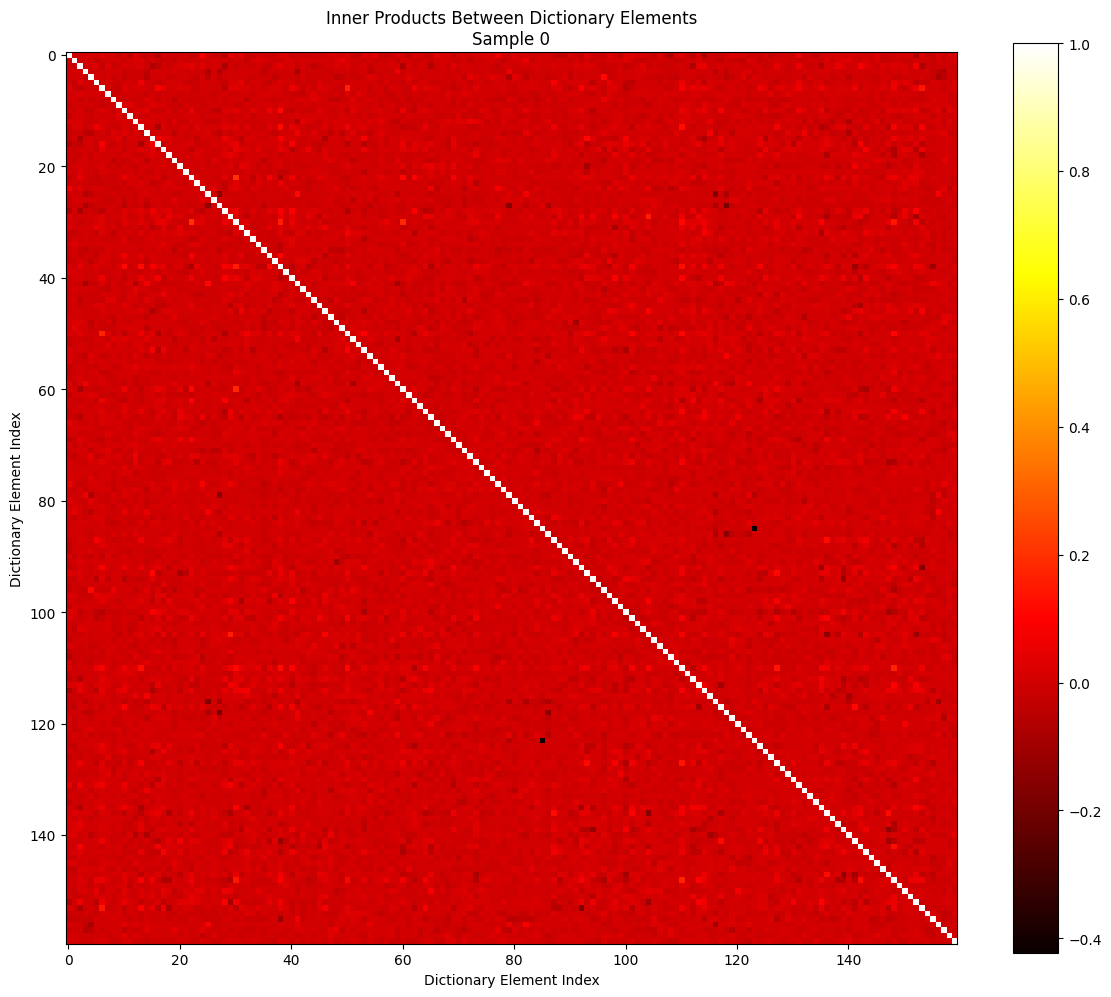

Min value: -0.1865, Max value: 1.0000


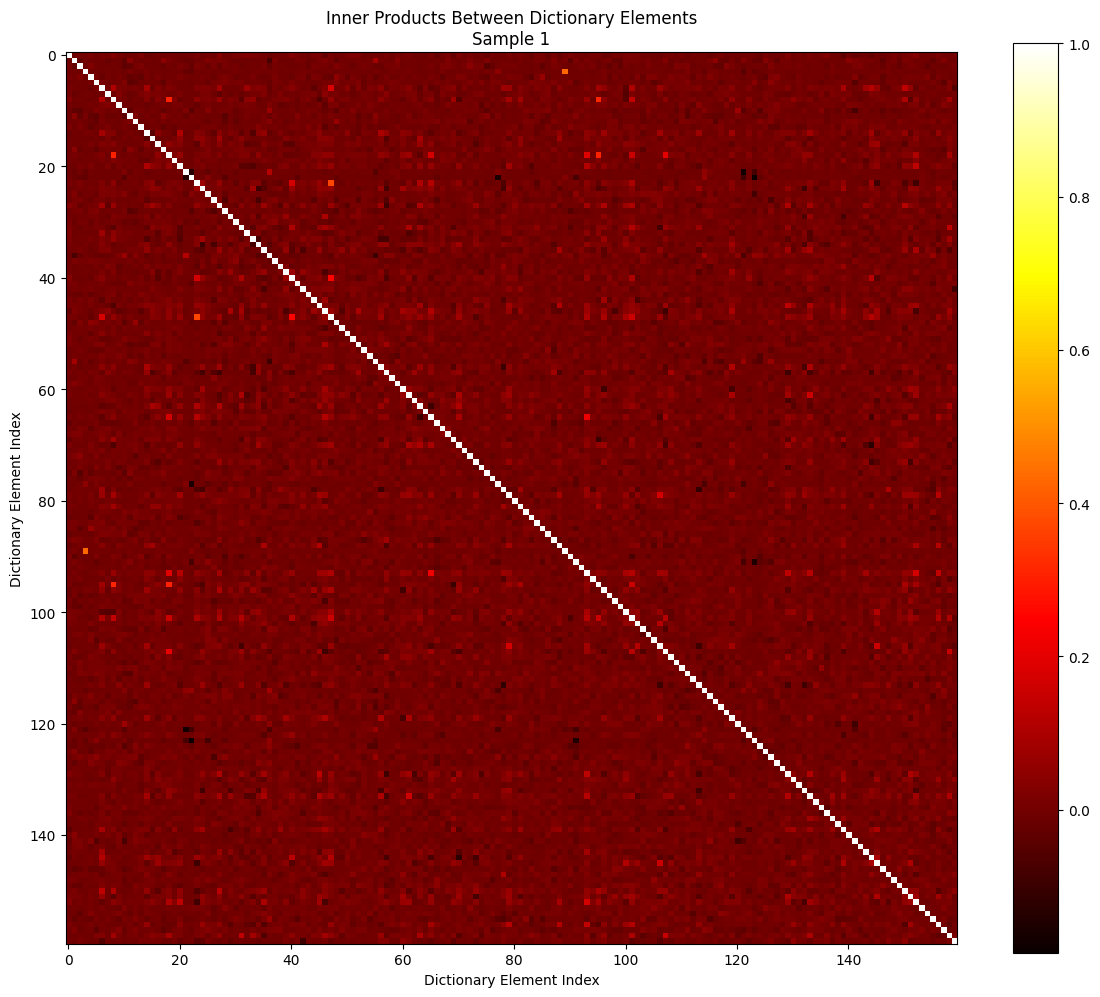

Min value: -0.1865, Max value: 1.0000


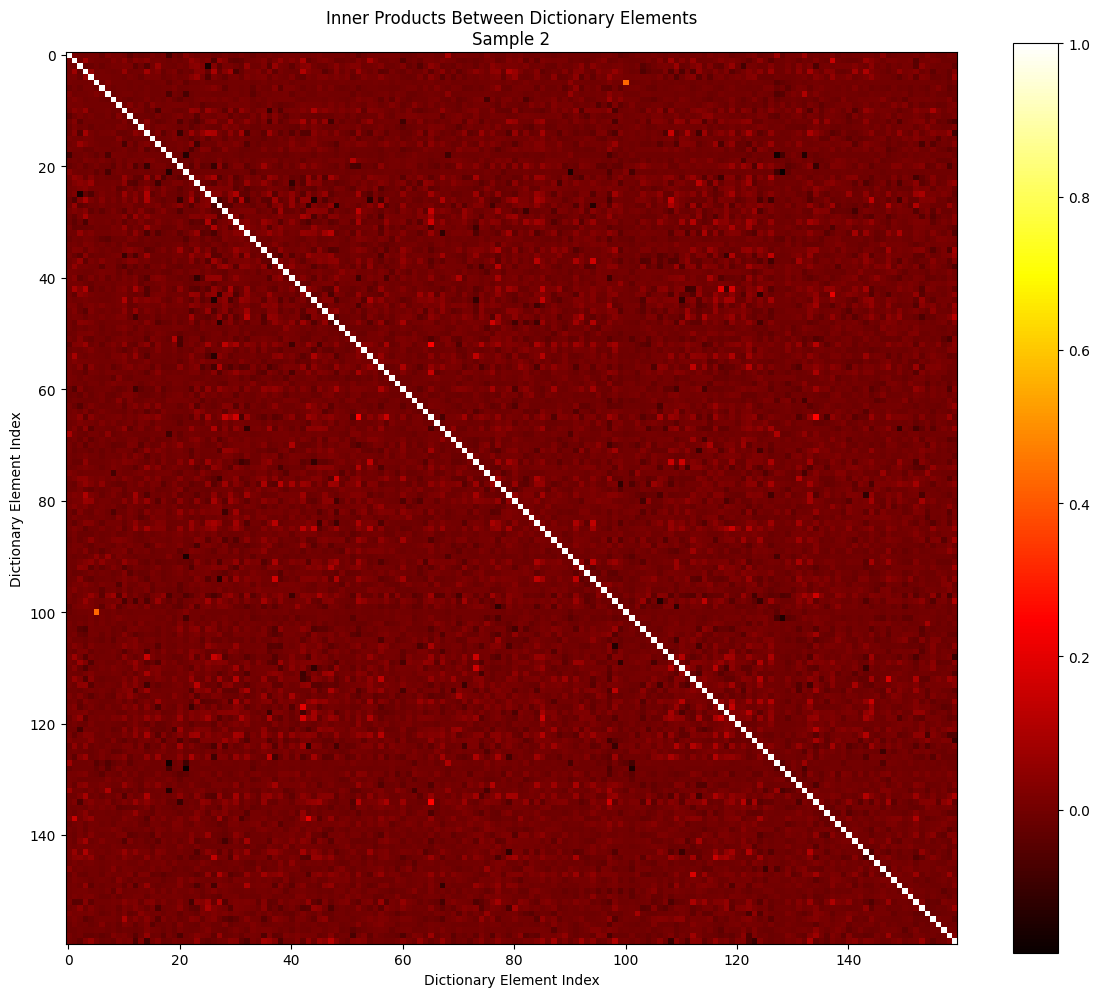

In [102]:
import numpy as np

import matplotlib.pyplot as plt

for j in range(3):
    # Get the first sample's projection matrix
    mat = proj_dirs_mat[j,:,:].cpu().numpy()

    # Create a figure with a larger size for better readability
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot the heatmap
    im = ax.imshow(mat, cmap='hot', interpolation='nearest')

    # Add a color bar
    cbar = plt.colorbar(im)

    # Set title and labels
    ax.set_title(f'Inner Products Between Dictionary Elements\nSample {j}')
    ax.set_xlabel('Dictionary Element Index')
    ax.set_ylabel('Dictionary Element Index')

    # If the matrix is not too large, we can add text annotations
    if mat.shape[0] <= 40:  # Only add text if the matrix is not too large
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                text = ax.text(j, i, f'{mat[i, j]:.2f}',
                            ha="center", va="center", color="black" if mat[i, j] < 0.7 else "white",
                            fontsize=8)

    # Calculate and print the range of values
    min_val = np.min(mat)
    max_val = np.max(mat)
    print(f"Min value: {min_val:.4f}, Max value: {max_val:.4f}")

    plt.tight_layout()
    plt.show()

In [103]:
## Replacing decoder with least-squares projection
n_val_batches = 1
with t.no_grad():
    autoenc_unexplained_variance = t.zeros(activation_dim, device=device, dtype=dtype)
    proj_unexplained_variance = t.zeros(activation_dim, device=device, dtype=dtype)
    for i in tqdm(range(n_val_batches)):
        x = next(activation_buffer).to(device)
        enc_x, _, k_indices, _ = autoencoder.encode(x, return_topk = True)
        proj_dirs = autoencoder.decoder.weight.T[k_indices]
        # print(proj_dirs[2,10,:10])
        # print(autoencoder.decoder.weight.T[k_indices[2,10],:10])
        # print(enc_x.shape, k_indices.shape)
        # enc_x is of shape (batch_size, activation_dim)
        # k_indices is of shape (batch_size, k)
        # create a new tensor enc_x_topk of shape (batch_size, k) where
        # enc_x_topk[b, i] = enc_x[b, k_indices[b, i]]
        enc_x_topk = enc_x[t.arange(enc_x.shape[0]).unsqueeze(1), k_indices]
        # print(enc_x_topk)
        # print(enc_x)
        # print(enc_x_topk.shape)
        # proj_dirs is of shape (batch_size, dict_size, activation_dim)
        x_to_fit = x - autoencoder.b_dec
        # fit x_to_fit with least squares to proj_dirs
        # swap last two dimensions of proj_dirs to (activation_dim, dict_size)
        proj_dirs = proj_dirs.permute(0, 2, 1)
        alpha = t.linalg.lstsq(proj_dirs, x_to_fit.unsqueeze(-1)).solution.squeeze(-1)
        proj_x = t.einsum('bdk,bk->bd', proj_dirs, alpha) + autoencoder.b_dec
        proj_x_err = x - proj_x
        proj_unexplained_variance += t.mean((proj_x_err) ** 2, dim=0)
        dec_x = autoencoder.decode(enc_x)
        print(dec_x - proj_x)
        err_x = dec_x - x
        autoenc_unexplained_variance += t.mean(err_x ** 2, dim=0)
    autoenc_unexplained_variance /= n_val_batches
    proj_unexplained_variance /= n_val_batches
    tot_unexplained_variance = t.sum(autoenc_unexplained_variance)
    tot_proj_unexplained_variance = t.sum(proj_unexplained_variance)
print('Total variance:', tot_variance.item())
print('Total autoencoder unexplained variance:', tot_unexplained_variance.item())
print('Total projection unexplained variance:', tot_proj_unexplained_variance.item())
print('Fraction autoencoder unexplained variance:', tot_unexplained_variance.item() / tot_variance.item())
print('Fraction projection unexplained variance:', tot_proj_unexplained_variance.item() / tot_variance.item())

  0%|                                                                                                                                                                                                                                                                              | 0/1 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.82s/it]

tensor([[ 0.0323,  0.1459,  0.0269,  ..., -0.0443,  0.0841, -0.0756],
        [-0.0440, -0.0063, -0.0876,  ..., -0.0454, -0.0384, -0.0170],
        [-0.0196,  0.1084, -0.0066,  ...,  0.1283, -0.0917, -0.1274],
        ...,
        [-0.0356, -0.0793,  0.0681,  ...,  0.0619, -0.0718,  0.0275],
        [-0.0877,  0.0316,  0.0385,  ..., -0.0561,  0.0378,  0.0417],
        [ 0.0180, -0.1131, -0.0535,  ...,  0.1333, -0.0871,  0.1409]],
       device='cuda:0')
Total variance: 496.09521484375
Total autoencoder unexplained variance: 44.26276779174805
Total projection unexplained variance: 40.34002685546875
Fraction autoencoder unexplained variance: 0.08922232359304057
Fraction projection unexplained variance: 0.08131508962079836


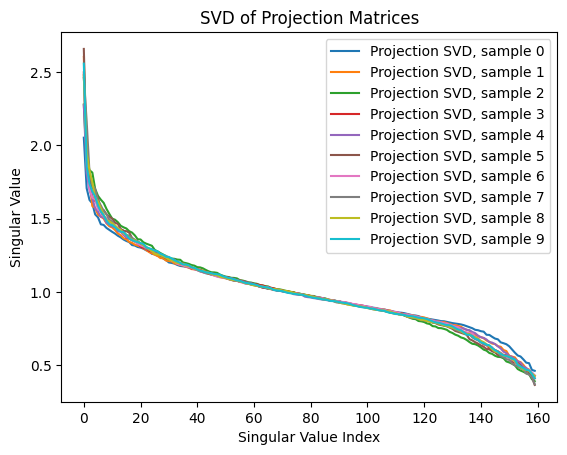

In [104]:
with t.no_grad():
    for j in range(10):
        plt.plot(t.svd(proj_dirs_mat[j,:,:]).S.cpu().numpy(), label=f'Projection SVD, sample {j}')
    plt.legend()
    plt.title('SVD of Projection Matrices')
    plt.xlabel('Singular Value Index')
    plt.ylabel('Singular Value')
    plt.show()

In [105]:
t.count_nonzero(enc_x,dim=1)

tensor([160, 160, 160,  ..., 160, 160, 160], device='cuda:0')

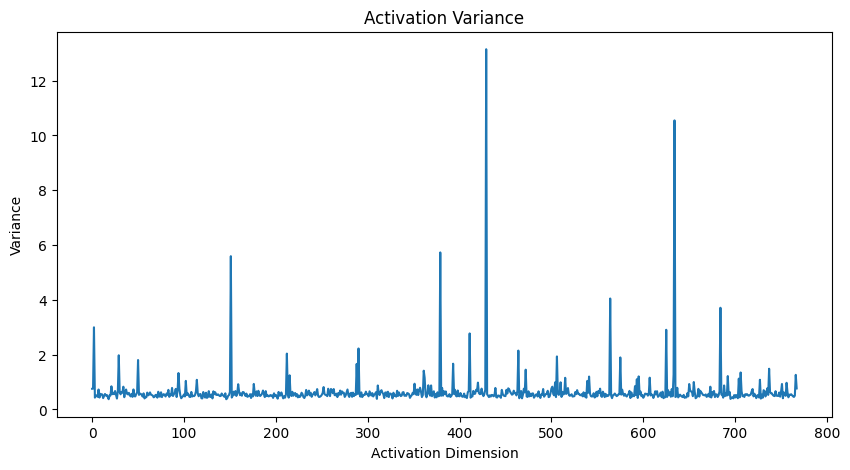

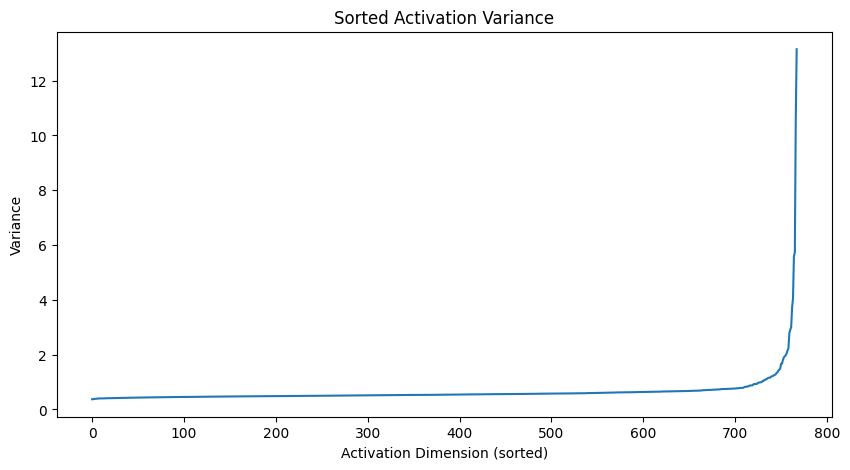

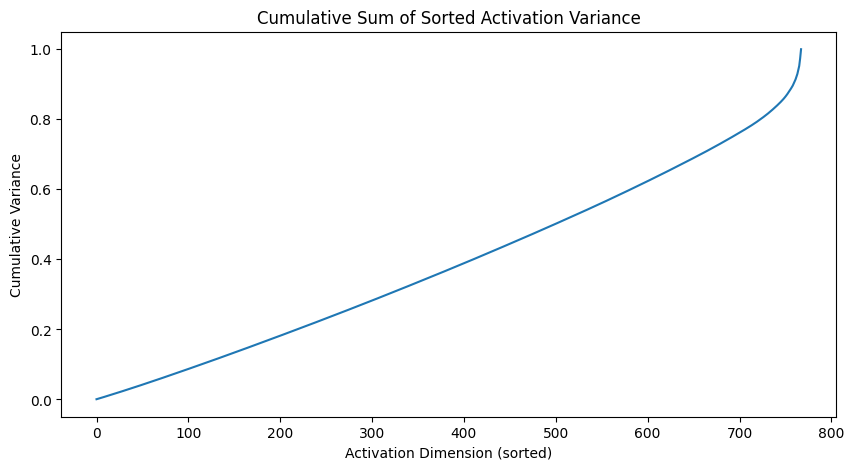

In [106]:
# plot activation_variance
plt.figure(figsize=(10, 5))
plt.plot(activation_variance.cpu().numpy())
plt.title('Activation Variance')
plt.xlabel('Activation Dimension')
plt.ylabel('Variance')
plt.show()

# sort activation variance and plot that
sorted_variance, sorted_indices = t.sort(activation_variance)
plt.figure(figsize=(10, 5))
plt.plot(sorted_variance.cpu().numpy())
plt.title('Sorted Activation Variance')
plt.xlabel('Activation Dimension (sorted)')
plt.ylabel('Variance')
plt.show()

# plot cumulative sum of sorted variance
plt.figure(figsize=(10, 5))
plt.plot(t.cumsum(sorted_variance, 0).cpu().numpy() / tot_variance.item())
plt.title('Cumulative Sum of Sorted Activation Variance')
plt.xlabel('Activation Dimension (sorted)')
plt.ylabel('Cumulative Variance')
plt.show()


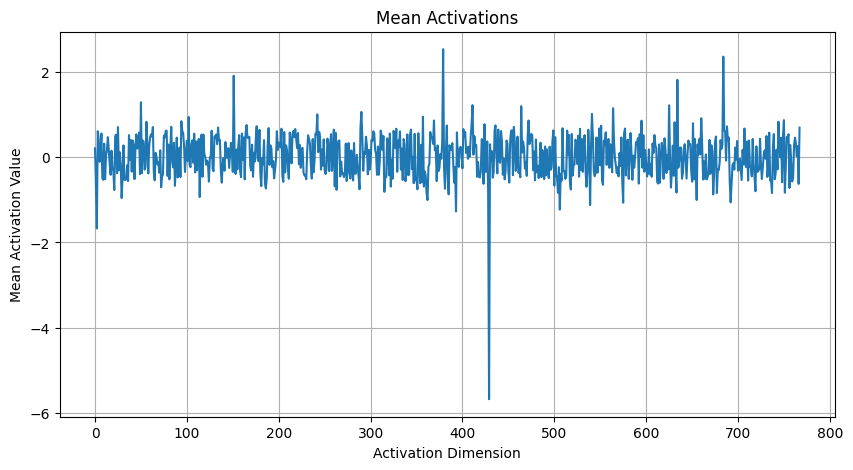

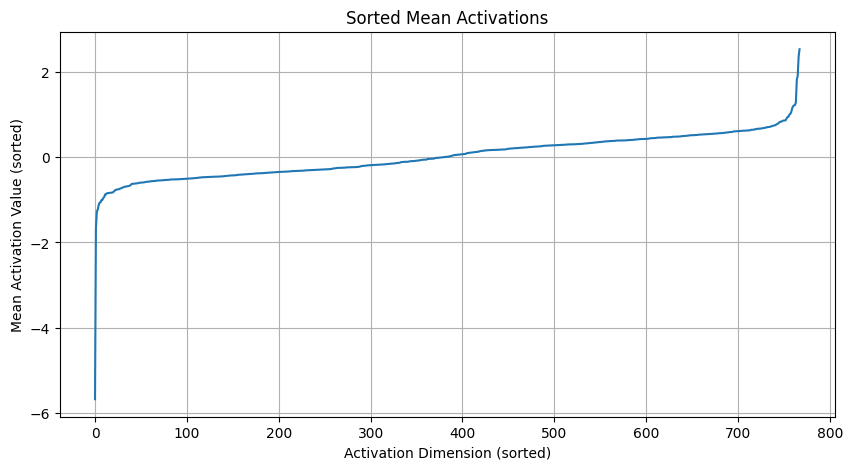

In [107]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title('Mean Activations')
plt.xlabel('Activation Dimension')
plt.ylabel('Mean Activation Value')
plt.grid()
plt.plot(mean_activations.cpu().numpy())
plt.show()
# sort mean activations and plot that
sorted_mean_activations, sorted_indices = t.sort(mean_activations)
plt.figure(figsize=(10, 5))
plt.plot(sorted_mean_activations.cpu().numpy())
plt.title('Sorted Mean Activations')
plt.xlabel('Activation Dimension (sorted)')
plt.ylabel('Mean Activation Value (sorted)')
plt.grid()
plt.show()

In [108]:
n_val_batches = 100
batch_size = config_data['buffer']['out_batch_size']

dict_size = autoencoder.encoder.out_features
freq_active = t.zeros(dict_size, dtype=t.int32, device=device)
for i in tqdm(range(n_val_batches)):
    x = next(activation_buffer).to(device)
    reconstruction, internal_layer = autoencoder(x, output_features=True)
    freq_active += t.count_nonzero(internal_layer, dim=0)
frac_active = freq_active / (batch_size * n_val_batches)


  0%|                                                                                                                                                                                                                                                                            | 0/100 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.90it/s]


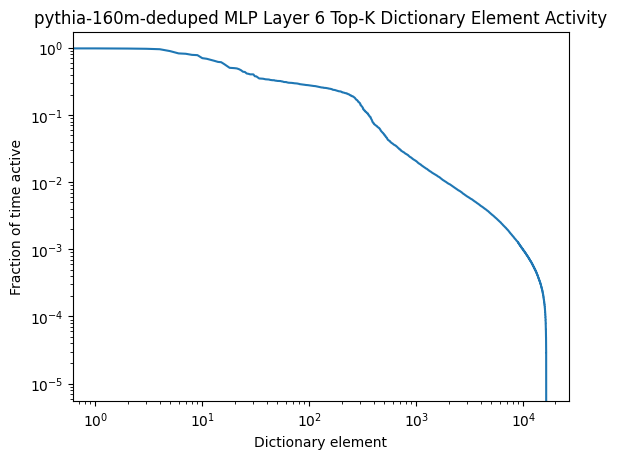

In [111]:
import matplotlib.pyplot as plt
frac_active_numpy = frac_active.cpu().numpy()
frac_active_numpy[::-1].sort()
plt.plot(frac_active_numpy)
plt.ylabel('Fraction of time active')
plt.xlabel('Dictionary element')
plt.yscale('log')
plt.xscale('log')
plt.title(f'{model_name.split('/')[-1]} MLP Layer {layer_idx} Top-K Dictionary Element Activity')
plt.show()

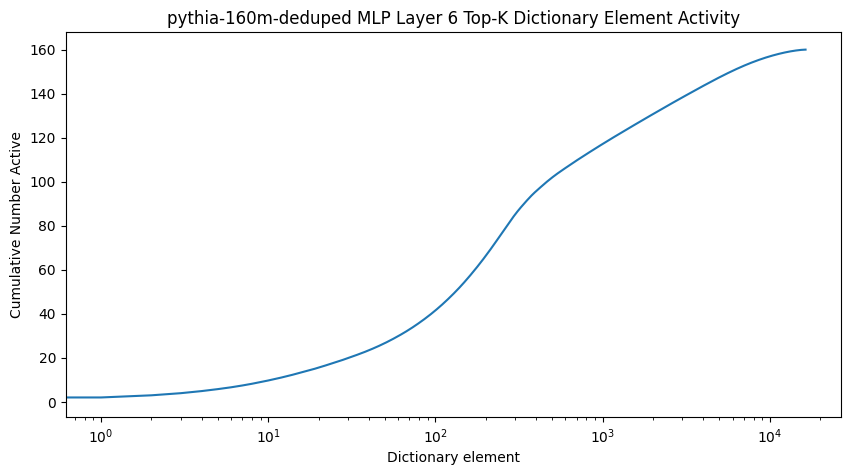

In [112]:
import matplotlib.pyplot as plt
frac_active_numpy = frac_active.cpu().numpy()
frac_active_numpy[::-1].sort()
cumsum = np.cumsum(frac_active_numpy)
plt.figure(figsize=(10, 5))
plt.plot(cumsum)
plt.ylabel('Cumulative Number Active')
plt.xlabel('Dictionary element')
# plt.yscale('log')
plt.xscale('log')
plt.title(f'{model_name.split('/')[-1]} MLP Layer {layer_idx} Top-K Dictionary Element Activity')
plt.show()

In [17]:
L = 10
# partition dict_size into L bins, where each index is random
def random_partition(dict_size, L):
    indices = list(range(dict_size))
    random.shuffle(indices)
    partition = [indices[i::L] for i in range(L)]
    return partition

def val_partition(partition, frac_active):
    """
    Returns the fraction of active elements in each partition.
    """
    tot_val = 0
    for S in partition:
        prob_inactive = 1
        for i in S:
            prob_inactive *= (1 - frac_active[i])
        tot_val += len(S) * (1-prob_inactive)
    return tot_val

curr_partition = random_partition(dict_size, L)

In [18]:
# partition 1/10 of elements into each bin, in contiguous order
cutoffs = [i * dict_size // L for i in range(L + 1)]
curr_partition = [list(range(cutoffs[i], cutoffs[i + 1])) for i in range(L)]

  0%|                                                                                                                                                                                                                                                                         | 0/100000 [00:00<?, ?it/s]

Iteration 0, Current partition value: 40179.515625


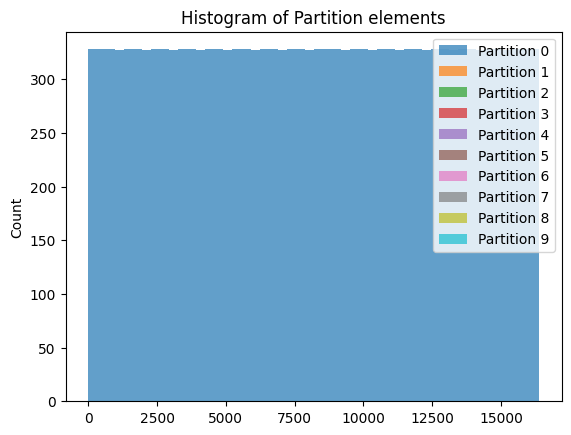

  0%|▋                                                                                                                                                                                                                                                            | 274/100000 [00:14<1:29:40, 18.53it/s]


KeyboardInterrupt: 

In [19]:
val_partition(curr_partition, frac_active_numpy)
curr_val = val_partition(curr_partition, frac_active_numpy)
for iter_num in tqdm(range((100000))):
    if iter_num % 1000 == 0:
        print(f'Iteration {iter_num}, Current partition value: {val_partition(curr_partition, frac_active_numpy)}')
        if iter_num % 1000 == 0:
            # for each partition, plot histogram of elements
            for i, S in enumerate(curr_partition):
                plt.hist(S, bins=50, range=(0,16384), alpha=0.7, label='Partition ' + str(i))
                plt.legend()
            plt.title(f'Histogram of Partition elements')
            plt.ylabel('Count')
            plt.show()
    # randomly move one element from one part of the partition to another
    i = random.randint(0, L-1)
    j = random.randint(0, L-1)
    if i == j:
        continue
    if len(curr_partition[i]) == 0 or len(curr_partition[j]) == 0:
        continue
    # move one randomly selected element from curr_partition[i] to curr_partition[j]
    elem = random.choice(curr_partition[i])
    curr_partition[i].remove(elem)
    curr_partition[j].append(elem)
    # compute new value
    new_val = val_partition(curr_partition, frac_active_numpy)
    # print(f'New value: {new_val}, Old value: {val_partition(curr_partition, frac_active_numpy)}')
    # if new_val is better, keep the partition
    if new_val < curr_val:
        curr_val = new_val
        continue
    else:
        # revert the change
        curr_partition[j].remove(elem)
        curr_partition[i].append(elem)
print('Final partition value:', val_partition(curr_partition, frac_active_numpy))

In [20]:
# partition 1/10 of elements into each bin, in contiguous order
L = 500
cutoffs = [i * dict_size // L for i in range(L+1)]

Iteration 0, Current partition value: 3786.203857421875


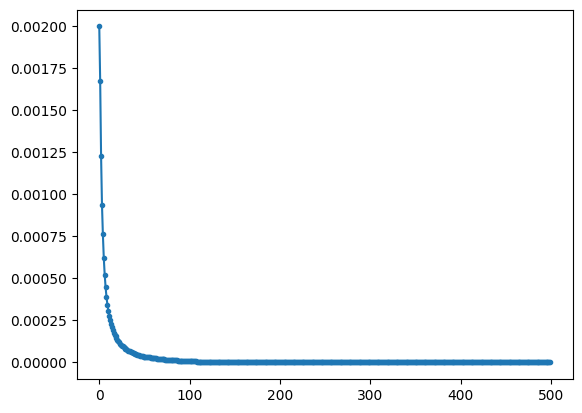

KeyboardInterrupt: 

In [21]:
curr_partition = [list(range(cutoffs[i], cutoffs[i + 1])) for i in range(L)]
curr_val = val_partition(curr_partition, frac_active_numpy)

for iter_num in range(100000):
    if iter_num % 1000 == 0:
        print(f'Iteration {iter_num}, Current partition value: {val_partition(curr_partition, frac_active_numpy)}')
        # if iter_num % 1000 == 0:
            # # for each partition, plot histogram of elements
            # for i, S in enumerate(curr_partition):
            #     plt.hist(S, bins=100, range=(0,16384), alpha=0.7, label='Partition ' + str(i))
            #     plt.legend()
            # plt.title(f'Histogram of Partition elements')
            # plt.ylabel('Count')
            # plt.show()
        partition_sizes = [len(S) / dict_size for S in curr_partition]
        probs_of_activity = [1 - np.prod(1 - frac_active_numpy[S]).item() for S in curr_partition]
        contribs = [probs_of_activity[i] * partition_sizes[i] for i in range(L)]
        # plt.plot(partition_sizes, label='partition sizes', marker='.')
        # plt.plot(probs_of_activity, label='probabilities of activity', marker='.')
        # plt.legend()
        # plt.show()
        plt.plot(contribs, label='contributions to value', marker='.')
        plt.show()
    # pick a random cutoff and move it to the left or right if possible
    idx = random.randint(1, L-1)
    h = 0
    rand_val = int(4*random.random())
    if random.random() < 0.5:
        # move left
        if cutoffs[idx] - cutoffs[idx-rand_val] > 1:
            h = -rand_val
    else:
        # move right
        if cutoffs[idx+1] - cutoffs[idx] > rand_val:
            h = rand_val
    if h == 0:
        continue
    cutoffs[idx] += h
    new_partition = [list(range(cutoffs[i], cutoffs[i + 1])) for i in range(L)]
    new_val = val_partition(new_partition, frac_active_numpy)
    if new_val < curr_val:
        curr_partition = new_partition
        curr_val = new_val
    else:
        # revert the change
        cutoffs[idx] -= h
print('Final partition value:', val_partition(curr_partition, frac_active_numpy))


In [48]:
import pickle
pickle.dump(frac_active_numpy, open('frac_active_numpy.pkl', 'wb'))


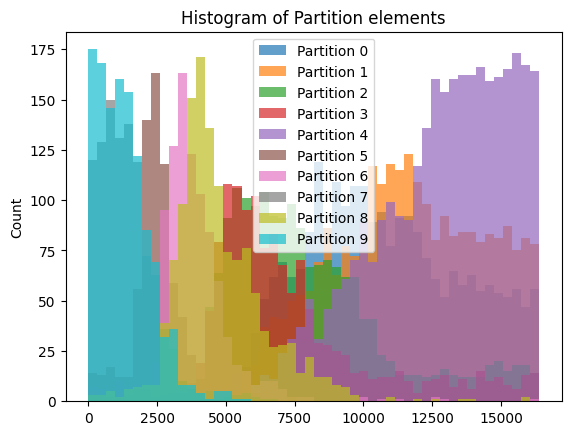

In [ ]:
# for each partition, plot histogram of elements
for i, S in enumerate(curr_partition):
    plt.hist(S, bins=50, range=(0,16384), alpha=0.7, label='Partition ' + str(i))
    plt.legend()
plt.title(f'Histogram of Partition elements')
plt.ylabel('Count')
plt.show()

In [22]:
# For each interval [0.1 to 1], [0.01 to 0.1], [0.001 to 0.01], [0.0001 to 0.001]
intervals = [
    (0.1, 1.0),
    (0.01, 0.1),
    (0.001, 0.01),
    (0.0001, 0.001),
]
# sample 5 features whose fraction of activation falls within the interval
features_within_intervals = {}
for low, high in intervals:
    indices = t.where((frac_active >= low) & (frac_active < high))[0]
    if len(indices) == 0:
        print(f'No features found in interval [{low}, {high})')
        continue
    sampled_indices = random.sample(indices.tolist(), min(5, len(indices)))
    print(f'Sampled features in interval [{low}, {high}): {sampled_indices}')
    features_within_intervals[(low, high)] = sampled_indices

Sampled features in interval [0.1, 1.0): [246828, 105661, 175827, 25918, 151336]
Sampled features in interval [0.01, 0.1): [6699, 18440, 36771, 216557, 111763]
Sampled features in interval [0.001, 0.01): [78507, 52773, 125469, 73031, 256841]
Sampled features in interval [0.0001, 0.001): [55119, 40658, 52778, 126558, 78171]


In [23]:
t.topk(frac_active, k=10)

torch.return_types.topk(
values=tensor([0.4648, 0.4490, 0.4148, 0.4107, 0.4008, 0.3998, 0.3669, 0.3447, 0.3405,
        0.3386], device='cuda:0'),
indices=tensor([ 48252, 220901,  10889,   8366, 133048,  81747,  34381, 261691,  11197,
        118792], device='cuda:0'))

In [24]:
feature_activ = {}
flat_features = []
for interval in intervals:
    for feature in features_within_intervals[interval]:
        feature_activ[feature] = []
        flat_features.append(feature)

for topk_val in [4216, 8553, 1189, 5993, 1044]:
    feature_activ[topk_val] = []
    flat_features.append(topk_val)

with t.no_grad():
    for i in range(n_val_batches):
        x = next(activation_buffer).to(device)
        reconstruction, internal_layer = autoencoder(x, output_features=True)
        for feature_idx in flat_features:
            if feature_idx in feature_activ:
                feature_activ[feature_idx].append(internal_layer[:, feature_idx].cpu())
    for feature_idx in tqdm(flat_features):
        feature_activ[feature_idx] = t.cat(feature_activ[feature_idx], dim=0)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 3649.89it/s]


In [25]:
# For each feature, what is the effect of adding or removing it from the input?
# E.g. zeroing out the projection to it? What is the right thing here -- 
# apply the network on the 

In [26]:
# for feature_idx in [4216, 8553, 1189, 5993, 1044]:
#     bias = autoencoder.encoder.bias[feature_idx].item()
#     encoder_norm = t.norm(autoencoder.encoder.weight[feature_idx,:]).item()
#     decoder_norm = t.norm(autoencoder.decoder.weight[:,feature_idx]).item()
#     plt.hist([a for a in feature_activ[feature_idx] if a != 0], bins=50, alpha=0.5, label=f'Feature {feature_idx} in {interval}')
#     plt.title(f'Activation Histogram for Feature {feature_idx} with frac_active {frac_active[feature_idx]} \n Bias {bias} \n Encoder Norm {encoder_norm} \n Decoder Norm {decoder_norm}')
#     plt.show()

(0.1, 1.0)


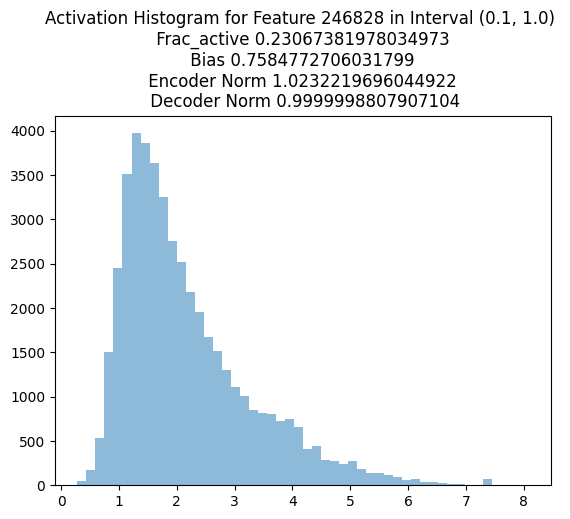

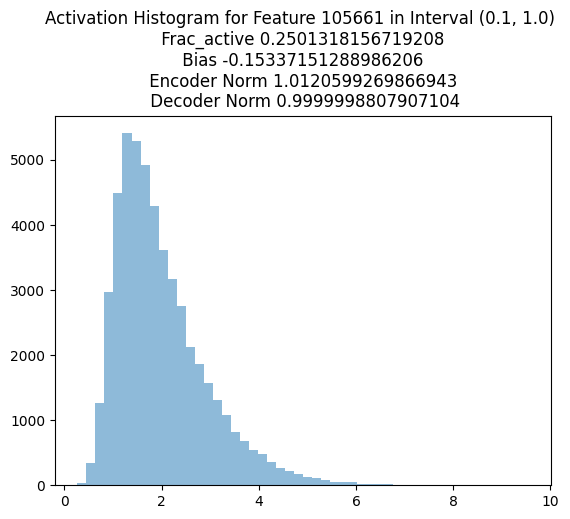

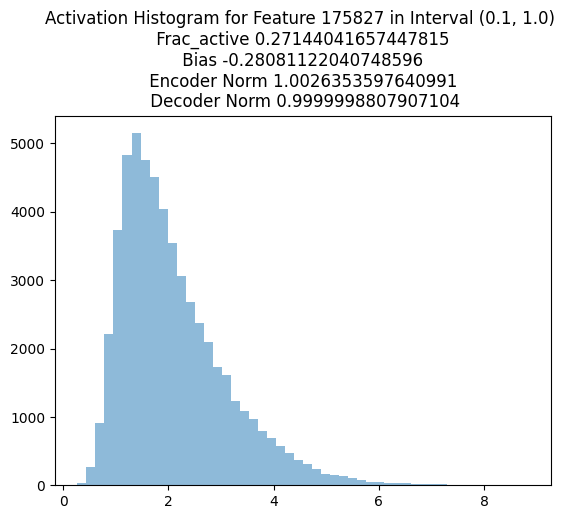

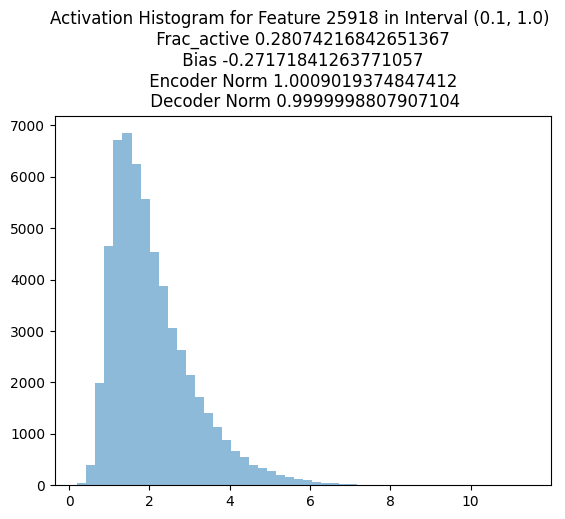

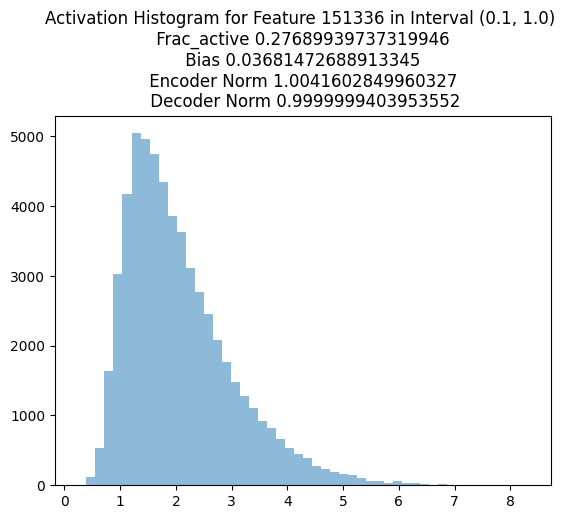

(0.01, 0.1)


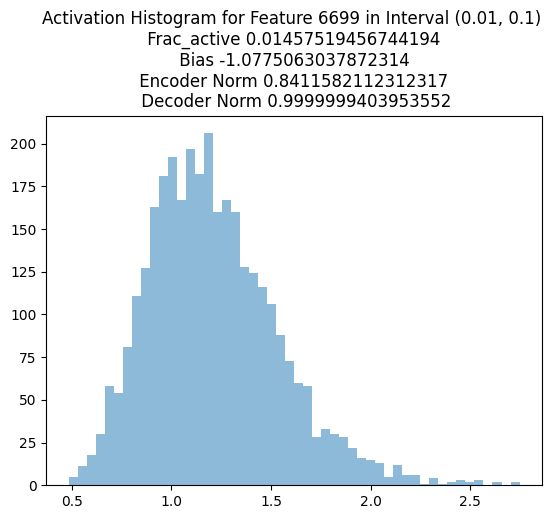

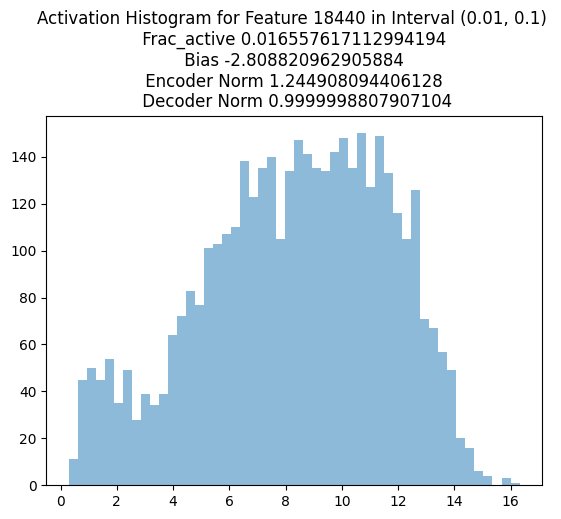

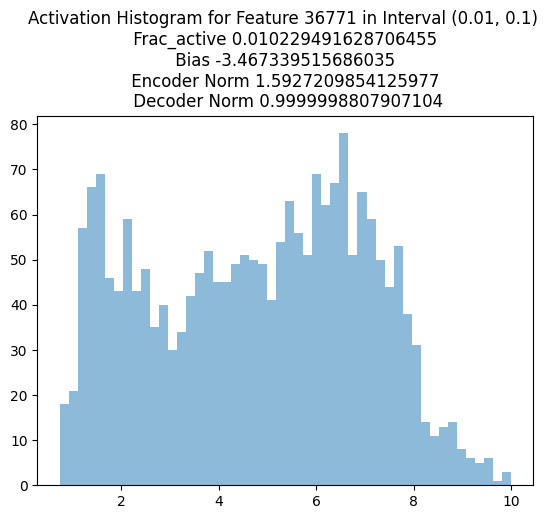

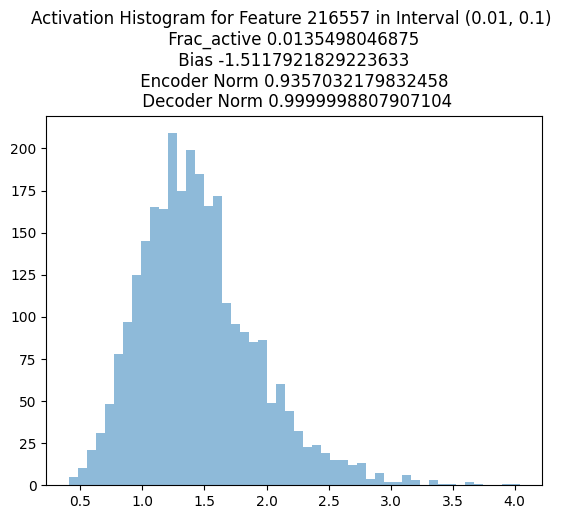

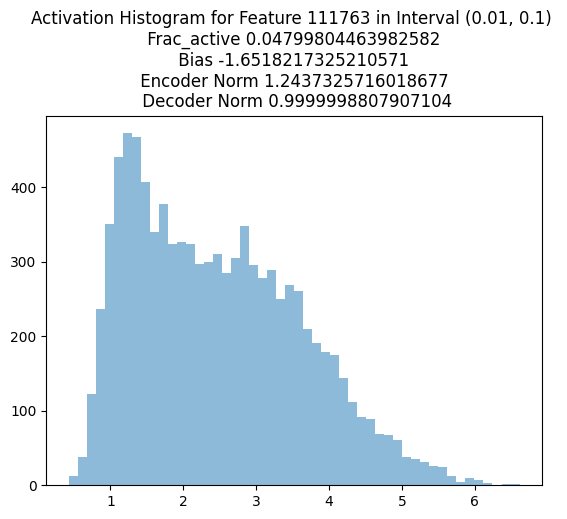

(0.001, 0.01)


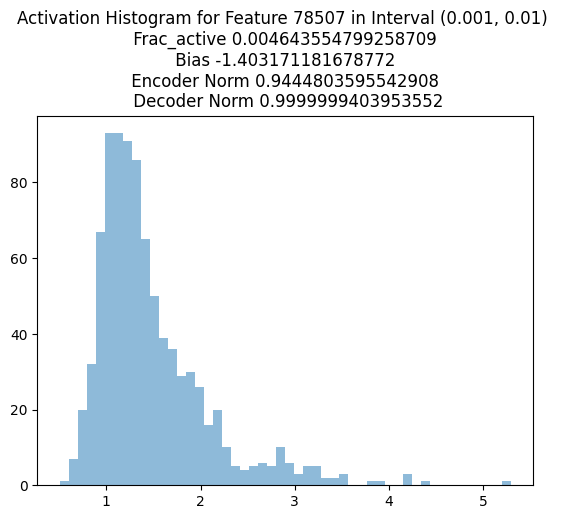

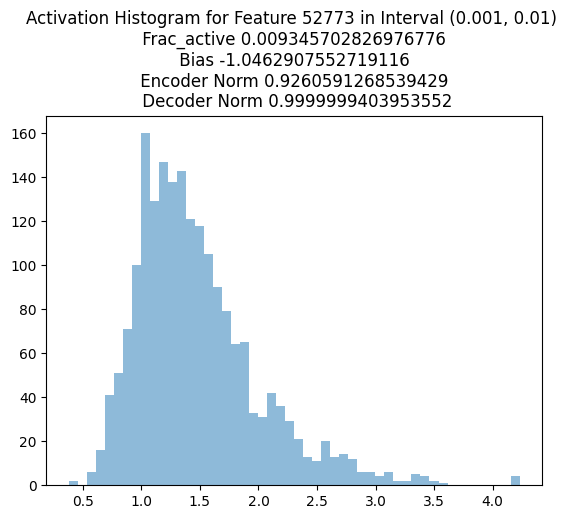

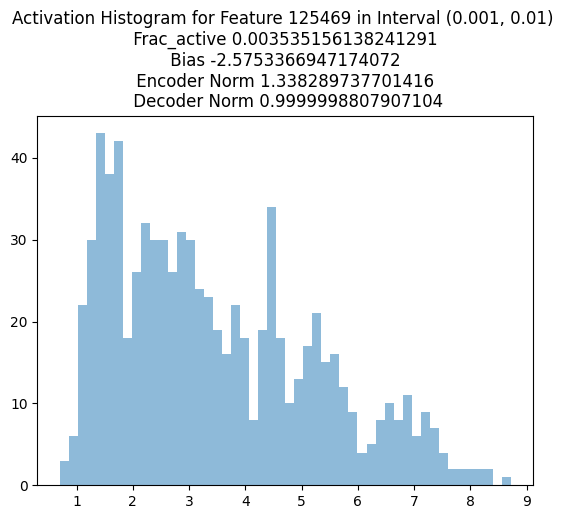

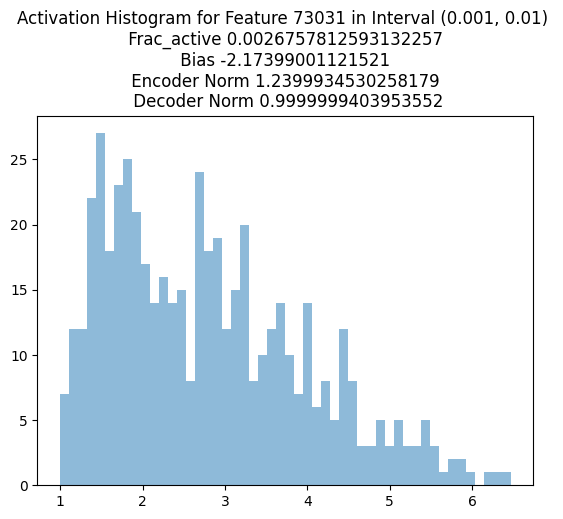

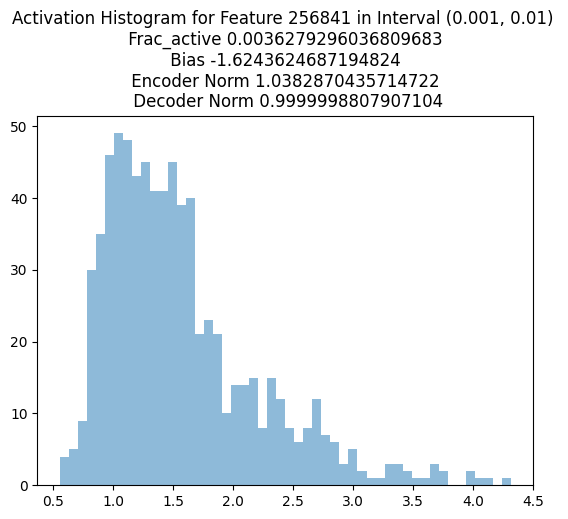

(0.0001, 0.001)


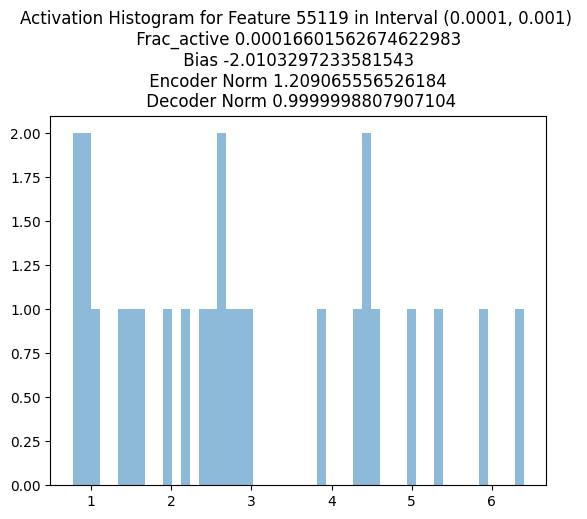

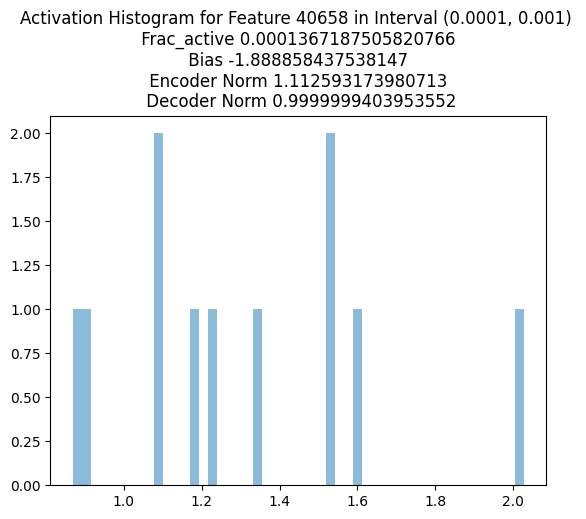

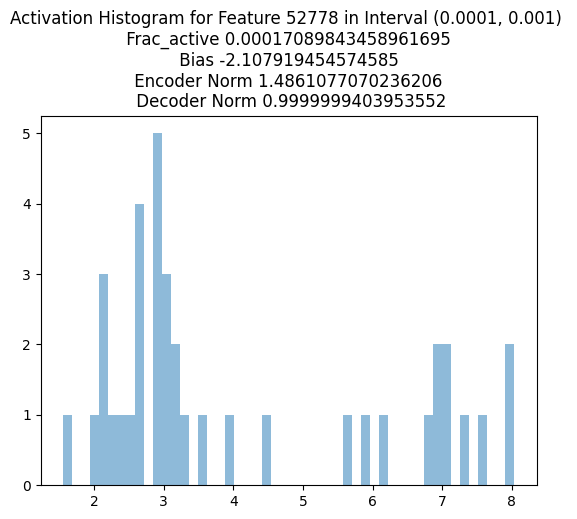

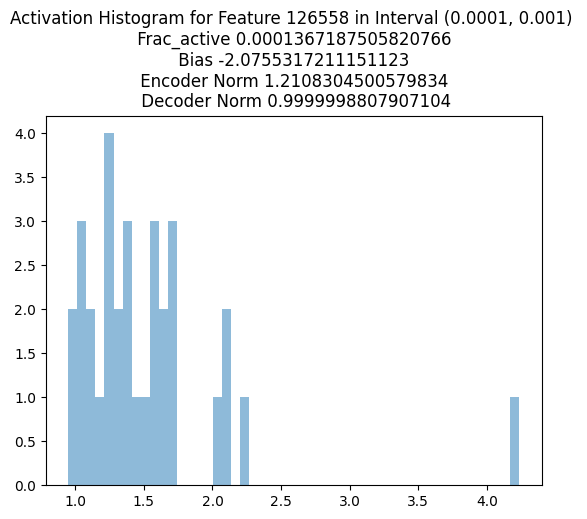

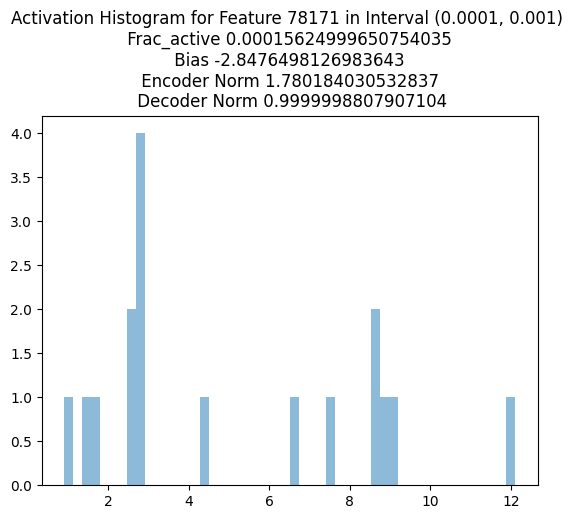

In [37]:
for interval in intervals:
    print(interval)
    for feature_idx in features_within_intervals[interval]:
        bias = autoencoder.encoder.bias[feature_idx].item()
        encoder_norm = t.norm(autoencoder.encoder.weight[feature_idx,:]).item()
        decoder_norm = t.norm(autoencoder.decoder.weight[:,feature_idx]).item()
        plt.hist([a for a in feature_activ[feature_idx] if a != 0], bins=50, alpha=0.5, label=f'Feature {feature_idx} in {interval}')
        plt.title(f'Activation Histogram for Feature {feature_idx} in Interval {interval} \n Frac_active {frac_active[feature_idx]} \n Bias {bias} \n Encoder Norm {encoder_norm} \n Decoder Norm {decoder_norm}')
        plt.show()

In [30]:
encoder_means = []
decoder_means = []
encoder_stds = []
decoder_stds = []
encoder_kurts = []
decoder_kurts = []
encoder_norms = []
for feature_idx in tqdm(range(dict_size)):
    # Compute kurtosis of encoder weight and decoder weight
    encoder_weight = autoencoder.encoder.weight[feature_idx, :]
    # plt.plot(encoder_weight.cpu().numpy(), label=f'Encoder Weight {feature_idx}')
    decoder_weight = autoencoder.decoder.weight[:, feature_idx]
    # plt.plot(decoder_weight.cpu().numpy(), label=f'Decoder Weight {feature_idx}')
    # plt.title(f'Weights for Feature {feature_idx} in Interval {interval}')
    # plt.xlabel('Weight Index')
    # plt.ylabel('Weight Value')
    # plt.legend()
    # plt.show()
    def compute_kurtosis(weight):
        if len(weight) < 4:
            return float('nan')
        mu = weight.mean()
        sigma = weight.std()
        kurt = ((weight - mu) ** 4).mean() / (sigma ** 4) - 3
        return mu, sigma, kurt
    encoder_mu, encoder_sigma, encoder_kurtosis = compute_kurtosis(encoder_weight)
    decoder_mu, decoder_sigma, decoder_kurtosis = compute_kurtosis(decoder_weight)
    encoder_norm = t.norm(encoder_weight).item()
    encoder_norms.append(encoder_norm)
    encoder_means.append(encoder_mu.item())
    decoder_means.append(decoder_mu.item())
    encoder_stds.append(encoder_sigma.item())
    decoder_stds.append(decoder_sigma.item())
    encoder_kurts.append(encoder_kurtosis.item())
    decoder_kurts.append(decoder_kurtosis.item())
    # print('Feature:'

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 262144/262144 [01:30<00:00, 2887.16it/s]


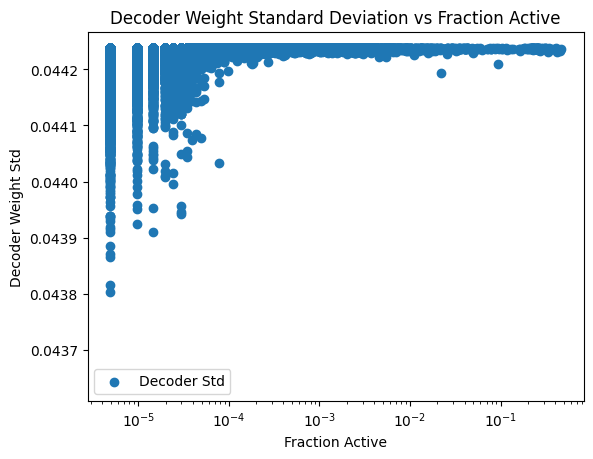

In [31]:
plt.scatter(frac_active.detach().cpu().numpy(), decoder_stds, label='Decoder Std')
plt.title('Decoder Weight Standard Deviation vs Fraction Active')
plt.xlabel('Fraction Active')
plt.ylabel('Decoder Weight Std')
plt.xscale('log')
plt.legend()
plt.show()

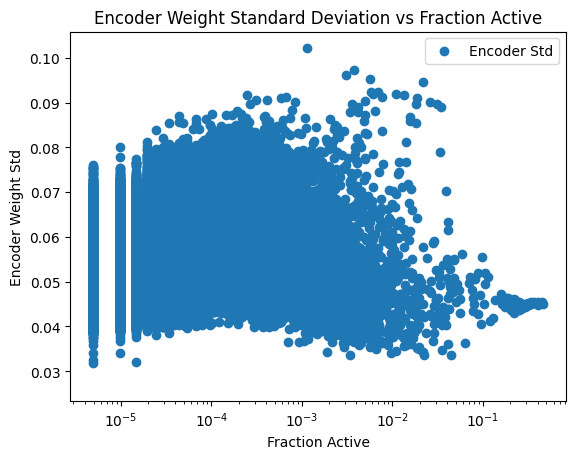

In [32]:
import numpy as np
plt.scatter(frac_active.detach().cpu().numpy(), np.asarray(encoder_stds), label='Encoder Std')
plt.title('Encoder Weight Standard Deviation vs Fraction Active')
plt.xlabel('Fraction Active')
plt.ylabel('Encoder Weight Std')
plt.xscale('log')
plt.legend()
plt.show()

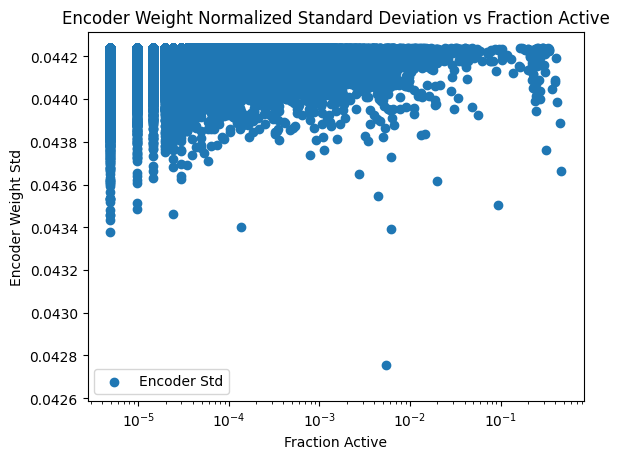

In [33]:
import numpy as np
plt.scatter(frac_active.detach().cpu().numpy(), np.asarray(encoder_stds) / np.asarray(encoder_norms), label='Encoder Std')
plt.title('Encoder Weight Normalized Standard Deviation vs Fraction Active')
plt.xlabel('Fraction Active')
plt.ylabel('Encoder Weight Std')
plt.xscale('log')
plt.legend()
plt.show()

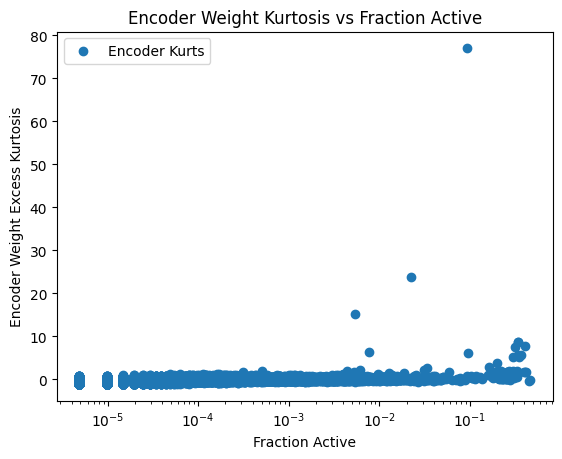

In [34]:
import numpy as np
plt.scatter(frac_active.detach().cpu().numpy(), np.asarray(encoder_kurts), label='Encoder Kurts')
plt.title('Encoder Weight Kurtosis vs Fraction Active')
plt.xlabel('Fraction Active')
plt.ylabel('Encoder Weight Excess Kurtosis')
plt.xscale('log')
plt.legend()
plt.show()

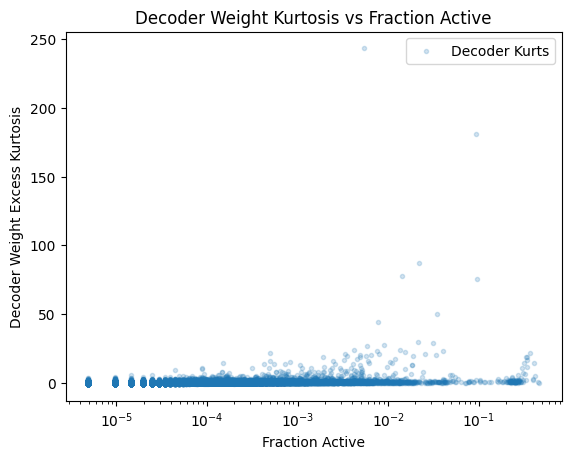

In [35]:
import numpy as np
plt.scatter(frac_active.detach().cpu().numpy(), np.asarray(decoder_kurts), label='Decoder Kurts', marker='.', alpha=0.2)
plt.title('Decoder Weight Kurtosis vs Fraction Active')
plt.xlabel('Fraction Active')
plt.ylabel('Decoder Weight Excess Kurtosis')
plt.xscale('log')
plt.legend()
plt.show()

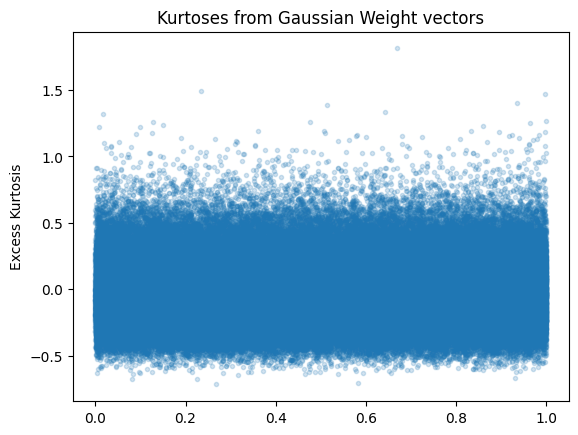

In [36]:
sample_kurtoses = [compute_kurtosis(t.randn(512)) for _ in range(dict_size)]
plt.scatter(t.rand(dict_size), [k[2] for k in sample_kurtoses], label='Sampled Kurtosis', marker='.', alpha=0.2)
plt.title('Kurtoses from Gaussian Weight vectors')
plt.ylabel('Excess Kurtosis')
plt.show()

In [9]:
import math

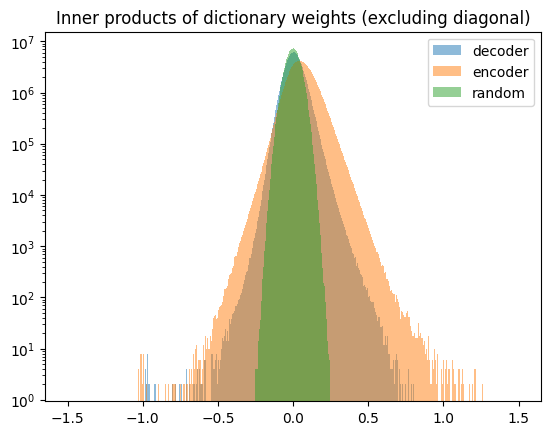

In [8]:
import math
with t.no_grad():

    We = autoencoder.decoder.weight.T
    WeWeT = We @ We.T
    sorted_inners = t.flatten(WeWeT - t.diag(WeWeT.diagonal()))
    plt.hist(sorted_inners.cpu().numpy(), bins=1000, alpha=0.5, label='decoder', range=(-1.5,1.5))
    
    We = autoencoder.encoder.weight
    WeWeT = We @ We.T
    sorted_inners = t.flatten(WeWeT - t.diag(WeWeT.diagonal()))
    plt.hist(sorted_inners.cpu().numpy(), bins=1000, alpha=0.5, label='encoder', range=(-1.5,1.5))

    We = t.randn(16384,512) / math.sqrt(512)
    WeWeT = We @ We.T
    sorted_inners = t.flatten(WeWeT - t.diag(WeWeT.diagonal()))
    plt.hist(sorted_inners.cpu().numpy(), bins=1000, alpha=0.5, label='random', range=(-1.5,1.5))
    plt.yscale('log')
    plt.legend()
    plt.title('Inner products of dictionary weights (excluding diagonal)')
    plt.show()


In [ ]:
plt.title('Inner Products of Encoder Weights')
plt.xlabel('Index')
plt.ylabel('Inner Product Value')
plt.show()

encoder_means = []
decoder_means = []
encoder_stds = []
decoder_stds = []
encoder_kurts = []
decoder_kurts = []
interval = 'top values'
features_within_intervals['top values'] = [4216, 8553, 1189, 5993, 1044]
with t.no_grad():
    for feature_idx in features_within_intervals[interval]:
        # Compute kurtosis of encoder weight and decoder weight
        encoder_weight = autoencoder.encoder.weight[feature_idx, :]
        plt.plot(encoder_weight.cpu().numpy(), label=f'Encoder Weight {feature_idx}', alpha=0.5)
        decoder_weight = autoencoder.decoder.weight[:, feature_idx]
        plt.plot(decoder_weight.cpu().numpy(), label=f'Decoder Weight {feature_idx}', alpha=0.5)
        plt.title(f'Weights for Feature {feature_idx} in Interval {interval}')
        plt.xlabel('Weight Index')
        plt.ylabel('Weight Value')
        plt.legend()
        plt.show()
        def compute_kurtosis(weight):
            if len(weight) < 4:
                return float('nan')
            mu = weight.mean()
            sigma = weight.std()
            kurt = ((weight - mu) ** 4).mean() / (sigma ** 4) - 3
            return mu, sigma, kurt
        encoder_mu, encoder_sigma, encoder_kurtosis = compute_kurtosis(encoder_weight)
        decoder_mu, decoder_sigma, decoder_kurtosis = compute_kurtosis(decoder_weight)
        encoder_means.append(encoder_mu.item())
        decoder_means.append(decoder_mu.item())
        encoder_stds.append(encoder_sigma.item())
        decoder_stds.append(decoder_sigma.item())
        encoder_kurts.append(encoder_kurtosis.item())
        decoder_kurts.append(decoder_kurtosis.item())
# Bar plot of means
plt.figure(figsize=(12, 6))
plt.bar(range(len(features_within_intervals[interval])), encoder_means, label='Encoder Means', alpha=0.5)
plt.bar(range(len(features_within_intervals[interval])), decoder_means, label='Decoder Means', alpha=0.5)
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.title(f'Mean Values of Encoder and Decoder Weights in Interval {interval}')
plt.legend()
plt.show()
# Bar plot of standard deviations
plt.figure(figsize=(12, 6))
plt.bar(range(len(features_within_intervals[interval])), encoder_stds, label='Encoder Std', alpha=0.5)
plt.bar(range(len(features_within_intervals[interval])), decoder_stds, label='Decoder Std', alpha=0.5)
plt.xlabel('Feature Index')
plt.ylabel('Standard Deviation')
plt.title(f'Standard Deviations of Encoder and Decoder Weights in Interval {interval}')
plt.legend()
plt.show()
# Bar plot of kurtosis
plt.figure(figsize=(12, 6))
plt.bar(range(len(features_within_intervals[interval])), encoder_kurts, label='Encoder Kurtosis', alpha=0.5)
plt.bar(range(len(features_within_intervals[interval])), decoder_kurts, label='Decoder Kurtosis', alpha=0.5)
plt.xlabel('Feature Index')
plt.ylabel('Kurtosis Value')
plt.title(f'Kurtosis of Encoder and Decoder Weights in Interval {interval}')
plt.legend()
plt.show()
        # print('Feature:'

(0.1, 1.0)


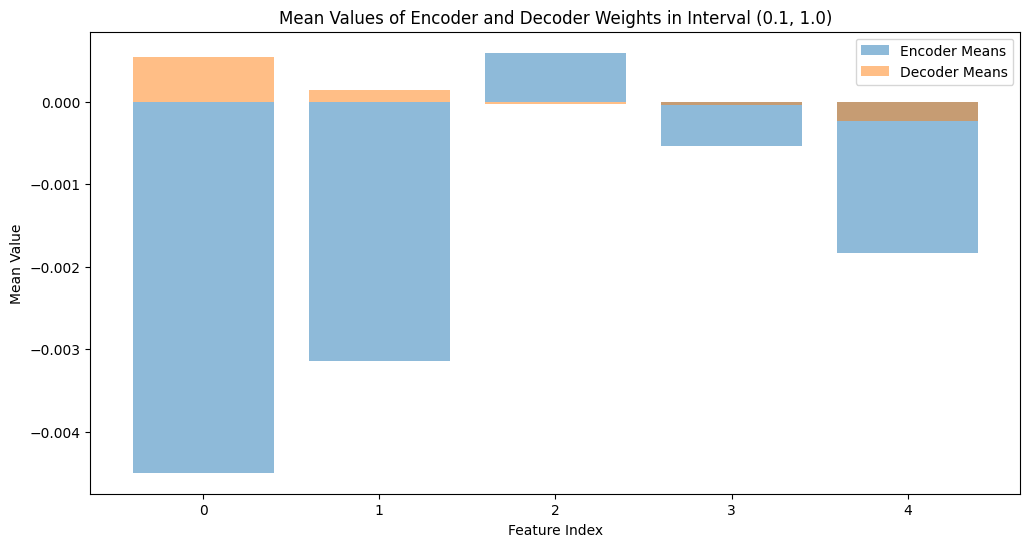

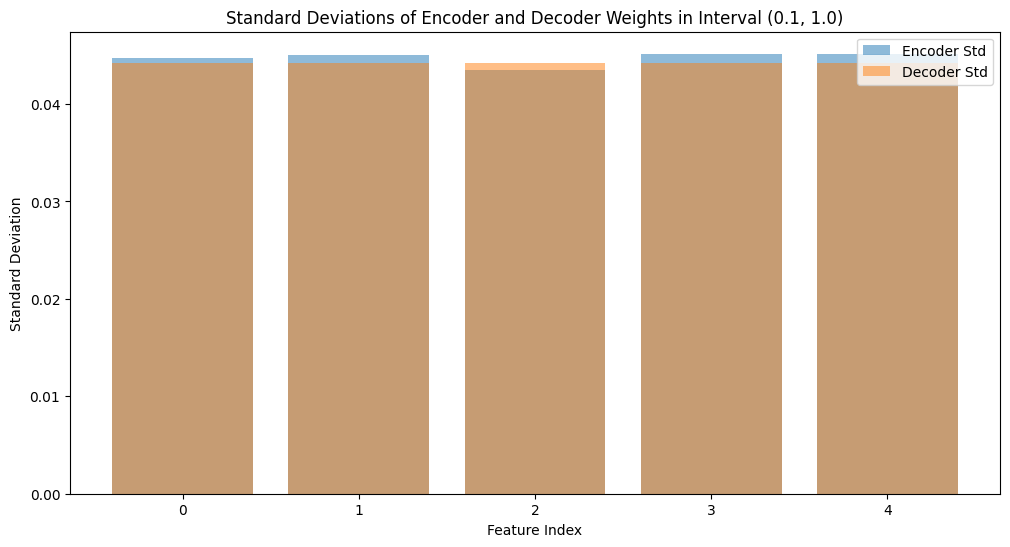

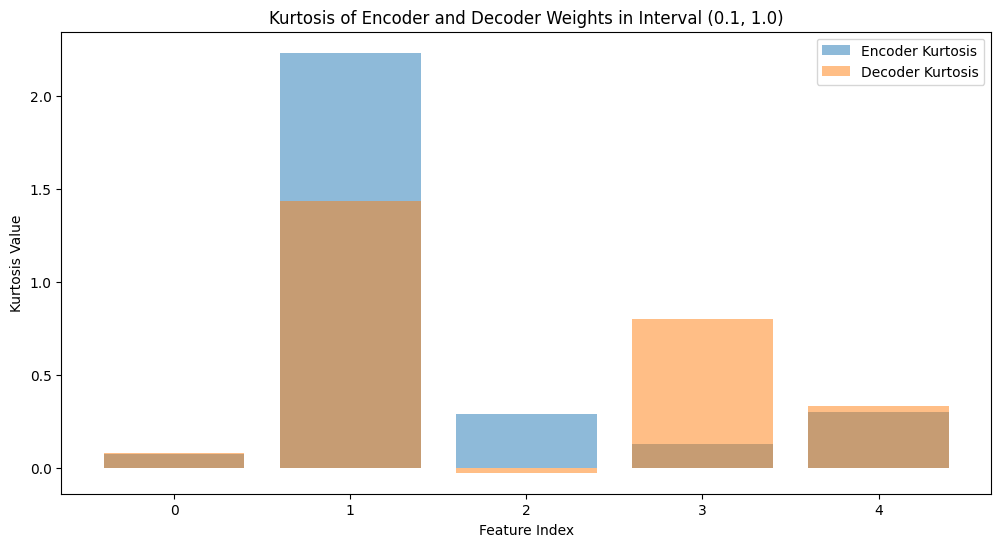

(0.01, 0.1)


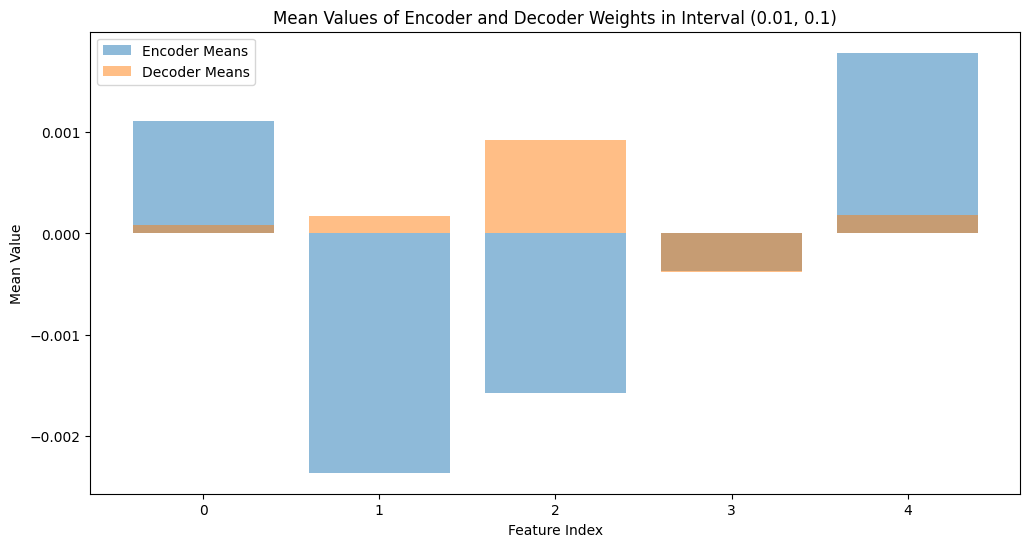

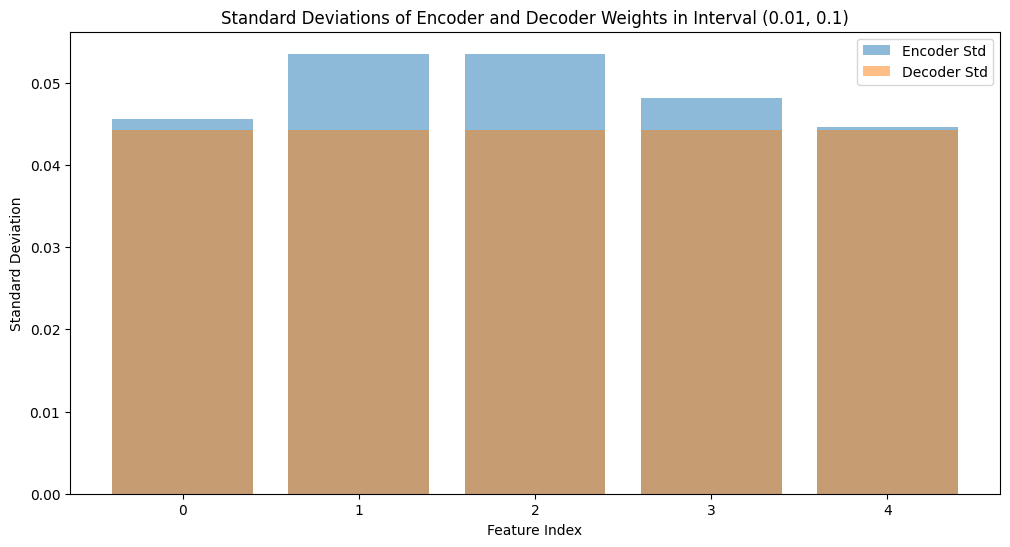

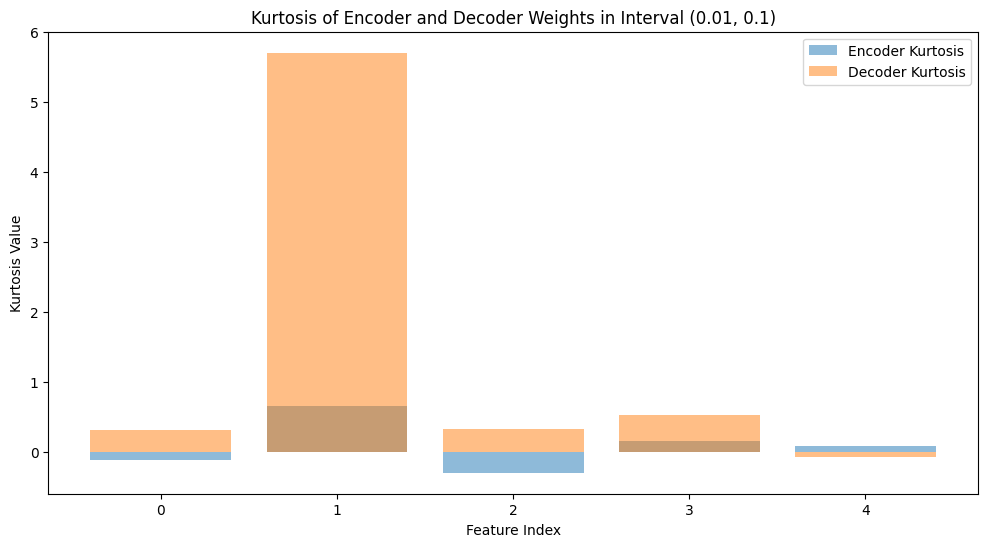

(0.001, 0.01)


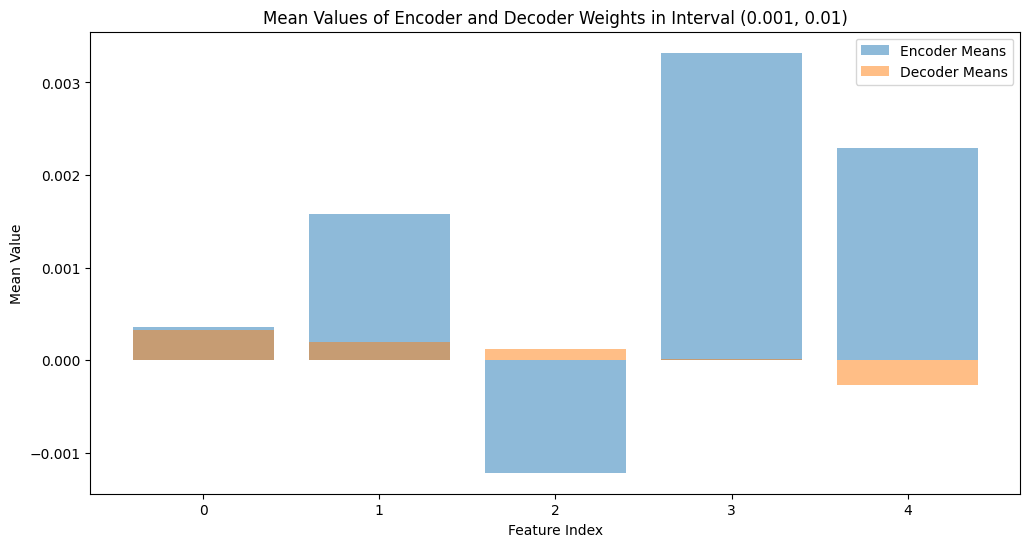

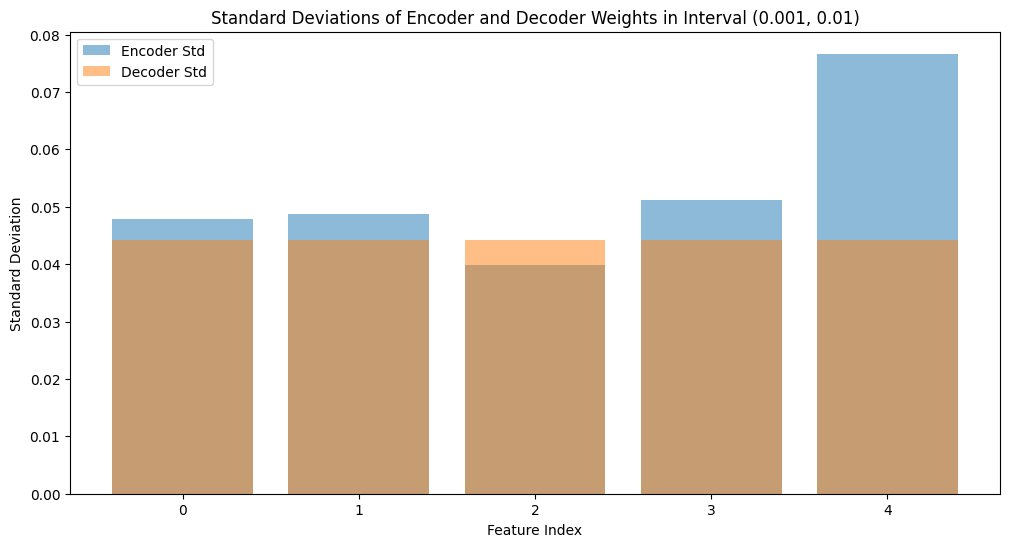

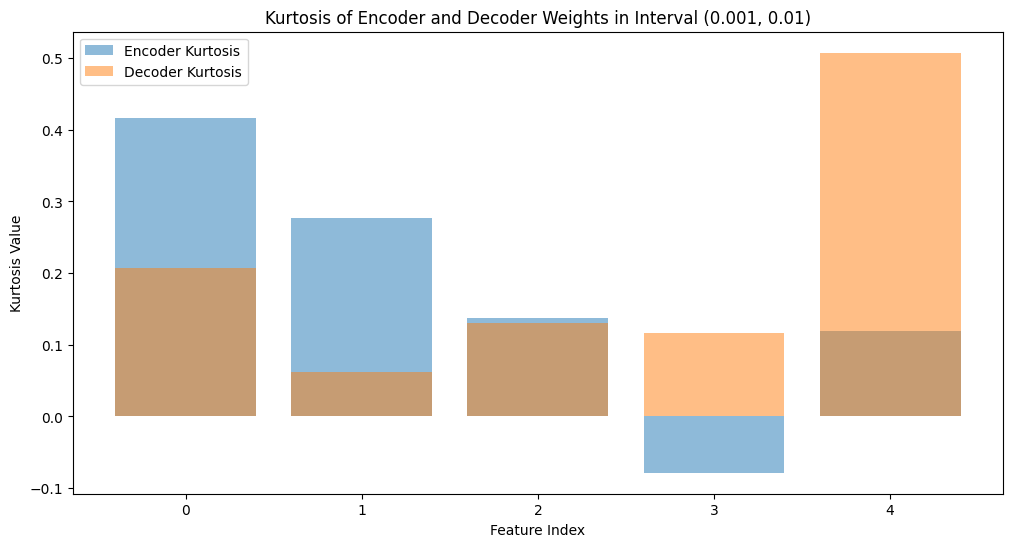

(0.0001, 0.001)


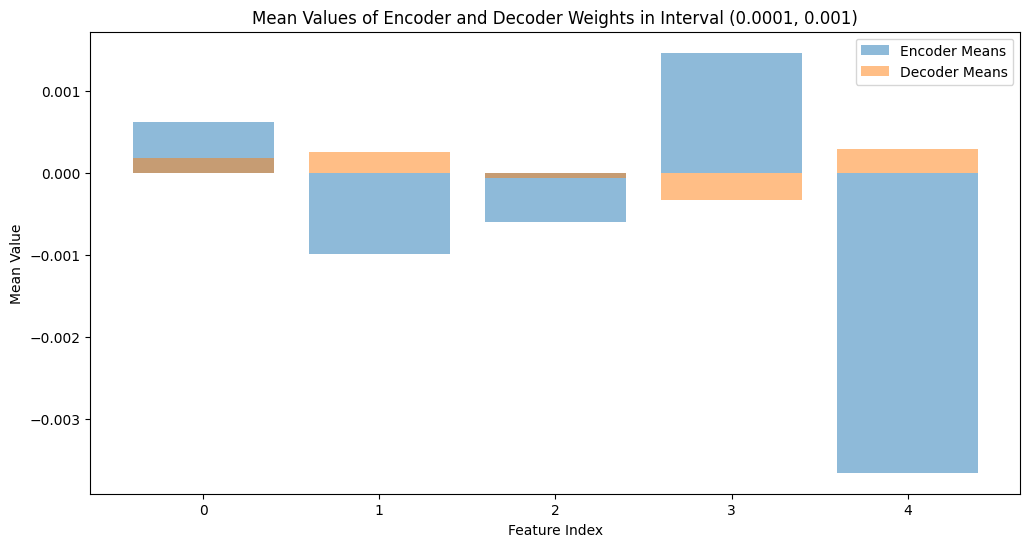

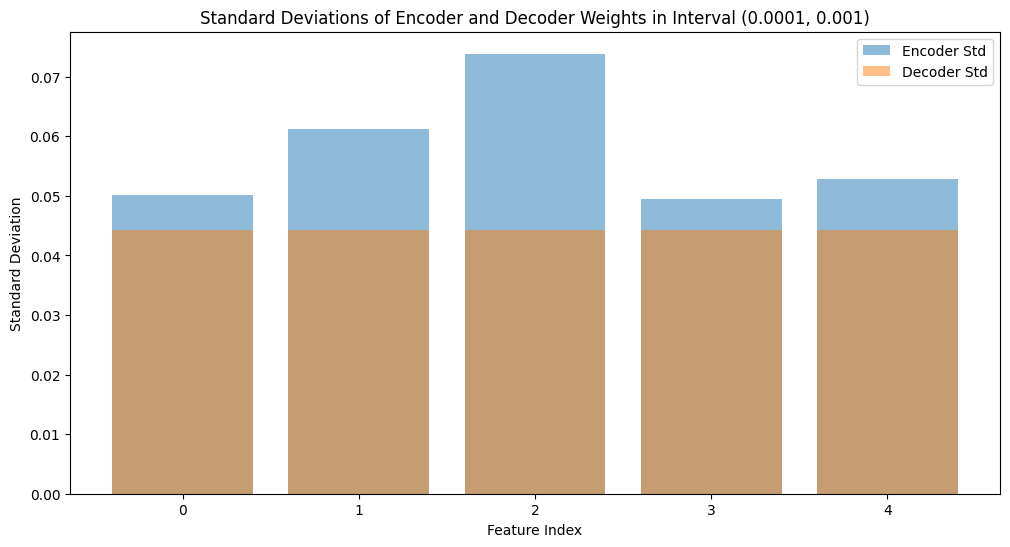

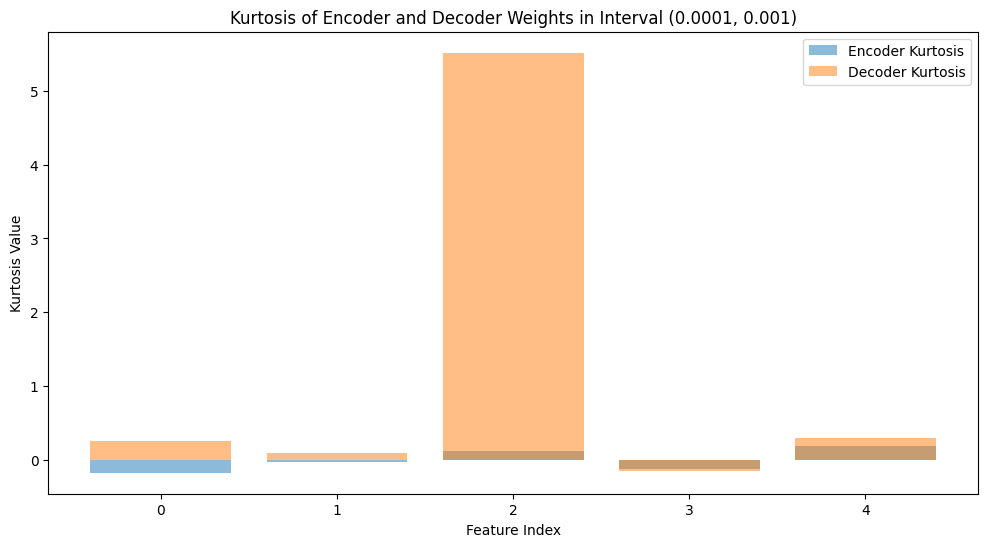

In [ ]:

for interval in intervals:
    encoder_means = []
    decoder_means = []
    encoder_stds = []
    decoder_stds = []
    encoder_kurts = []
    decoder_kurts = []
    print(interval)
    with t.no_grad():
        for feature_idx in features_within_intervals[interval]:
            # Compute kurtosis of encoder weight and decoder weight
            encoder_weight = autoencoder.encoder.weight[feature_idx, :]
            decoder_weight = autoencoder.decoder.weight[:, feature_idx]
            def compute_kurtosis(weight):
                if len(weight) < 4:
                    return float('nan')
                mu = weight.mean()
                sigma = weight.std()
                kurt = ((weight - mu) ** 4).mean() / (sigma ** 4) - 3
                return mu, sigma, kurt
            encoder_mu, encoder_sigma, encoder_kurtosis = compute_kurtosis(encoder_weight)
            decoder_mu, decoder_sigma, decoder_kurtosis = compute_kurtosis(decoder_weight)
            encoder_means.append(encoder_mu.item())
            decoder_means.append(decoder_mu.item())
            encoder_stds.append(encoder_sigma.item())
            decoder_stds.append(decoder_sigma.item())
            encoder_kurts.append(encoder_kurtosis.item())
            decoder_kurts.append(decoder_kurtosis.item())
    # Bar plot of means
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(features_within_intervals[interval])), encoder_means, label='Encoder Means', alpha=0.5)
    plt.bar(range(len(features_within_intervals[interval])), decoder_means, label='Decoder Means', alpha=0.5)
    plt.xlabel('Feature Index')
    plt.ylabel('Mean Value')
    plt.title(f'Mean Values of Encoder and Decoder Weights in Interval {interval}')
    plt.legend()
    plt.show()
    # Bar plot of standard deviations
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(features_within_intervals[interval])), encoder_stds, label='Encoder Std', alpha=0.5)
    plt.bar(range(len(features_within_intervals[interval])), decoder_stds, label='Decoder Std', alpha=0.5)
    plt.xlabel('Feature Index')
    plt.ylabel('Standard Deviation')
    plt.title(f'Standard Deviations of Encoder and Decoder Weights in Interval {interval}')
    plt.legend()
    plt.show()
    # Bar plot of kurtosis
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(features_within_intervals[interval])), encoder_kurts, label='Encoder Kurtosis', alpha=0.5)
    plt.bar(range(len(features_within_intervals[interval])), decoder_kurts, label='Decoder Kurtosis', alpha=0.5)
    plt.xlabel('Feature Index')
    plt.ylabel('Kurtosis Value')
    plt.title(f'Kurtosis of Encoder and Decoder Weights in Interval {interval}')
    plt.legend()
    plt.show()
            # print('Feature:', feature_idx)
            # print(f'Encoder - Mean: {encoder_mu}, Std: {encoder_sigma}, Kurtosis: {encoder_kurtosis}')
            # print(f'Decoder - Mean: {decoder_mu}, Std: {decoder_sigma}, Kurtosis: {decoder_kurtosis}')

In [ ]:
assert n_batches > 0
    out = defaultdict(float)
    active_features = t.zeros(dictionary.dict_size, dtype=t.float32, device=device)

    for _ in range(n_batches):
        try:
            x = next(activations).to(device)
            if normalize_batch:
                x = x / x.norm(dim=-1).mean() * (dictionary.activation_dim ** 0.5)
        except StopIteration:
            raise StopIteration(
                "Not enough activations in buffer. Pass a buffer with a smaller batch size or more data."
            )
        x_hat, f = dictionary(x, output_features=True)
        l2_loss = t.linalg.norm(x - x_hat, dim=-1).mean()
        l1_loss = f.norm(p=1, dim=-1).mean()
        l0 = (f != 0).float().sum(dim=-1).mean()
        
        features_BF = t.flatten(f, start_dim=0, end_dim=-2).to(dtype=t.float32) # If f is shape (B, L, D), flatten to (B*L, D)
        assert features_BF.shape[-1] == dictionary.dict_size
        assert len(features_BF.shape) == 2

        active_features += features_BF.sum(dim=0)

        # cosine similarity between x and x_hat
        x_normed = x / t.linalg.norm(x, dim=-1, keepdim=True)
        x_hat_normed = x_hat / t.linalg.norm(x_hat, dim=-1, keepdim=True)
        cossim = (x_normed * x_hat_normed).sum(dim=-1).mean()

        # l2 ratio
        l2_ratio = (t.linalg.norm(x_hat, dim=-1) / t.linalg.norm(x, dim=-1)).mean()

        #compute variance explained
        total_variance = t.var(x, dim=0).sum()
        residual_variance = t.var(x - x_hat, dim=0).sum()
        frac_variance_explained = (1 - residual_variance / total_variance)

        # Equation 10 from https://arxiv.org/abs/2404.16014
        x_hat_norm_squared = t.linalg.norm(x_hat, dim=-1, ord=2)**2
        x_dot_x_hat = (x * x_hat).sum(dim=-1)
        relative_reconstruction_bias = x_hat_norm_squared.mean() / x_dot_x_hat.mean()

        out["l2_loss"] += l2_loss.item()
        out["l1_loss"] += l1_loss.item()
        out["l0"] += l0.item()
        out["frac_variance_explained"] += frac_variance_explained.item()
        out["cossim"] += cossim.item()
        out["l2_ratio"] += l2_ratio.item()
        out['relative_reconstruction_bias'] += relative_reconstruction_bias.item()

        if not isinstance(activations, (ActivationBuffer, NNsightActivationBuffer)):
            continue

        # compute loss recovered
        loss_original, loss_reconstructed, loss_zero = loss_recovered(
            activations.text_batch(batch_size=batch_size),
            activations.model,
            activations.submodule,
            dictionary,
            max_len=max_len,
            normalize_batch=normalize_batch,
            io=io,
            tracer_args=tracer_args
        )
        frac_recovered = (loss_reconstructed - loss_zero) / (loss_original - loss_zero)
        
        out["loss_original"] += loss_original.item()
        out["loss_reconstructed"] += loss_reconstructed.item()
        out["loss_zero"] += loss_zero.item()
        out["frac_recovered"] += frac_recovered.item()

    out = {key: value / n_batches for key, value in out.items()}
    frac_alive = (active_features != 0).float().sum() / dictionary.dict_size
    out["frac_alive"] = frac_alive.item()

    return out

In [ ]:


reconstructed, features = autoencoder(input, output_features=True)

In [ ]:

@t.no_grad()
def eval_saes(
    model_name: str,
    ae_paths: list[str],
    n_inputs: int,
    device: str,
    overwrite_prev_results: bool = False,
    transcoder: bool = False,
) -> dict:
    random.seed(demo_config.random_seeds[0])
    t.manual_seed(demo_config.random_seeds[0])

    if transcoder:
        io = "in_and_out"
    else:
        io = "out"

    context_length = demo_config.LLM_CONFIG[model_name].context_length
    llm_batch_size = demo_config.LLM_CONFIG[model_name].llm_batch_size
    loss_recovered_batch_size = max(llm_batch_size // 5, 1)
    sae_batch_size = loss_recovered_batch_size * context_length
    dtype = demo_config.LLM_CONFIG[model_name].dtype

    max_layer = 0

    for ae_path in ae_paths:
        config_path = f"{ae_path}/config.json"

        with open(config_path, "r") as f:
            config = json.load(f)

        layer = config["trainer"]["layer"]
        max_layer = max(max_layer, layer)

    model = AutoModelForCausalLM.from_pretrained(
        model_name, device_map="auto", torch_dtype=dtype
    )

    model = utils.truncate_model(model, max_layer)

    buffer_size = n_inputs
    io = "out"
    n_batches = n_inputs // loss_recovered_batch_size

    generator = hf_dataset_to_generator("monology/pile-uncopyrighted", split='validation')

    input_strings = []
    for i, example in enumerate(generator):
        input_strings.append(example)
        if i > n_inputs * 5:
            break

    eval_results = {}

    for ae_path in ae_paths:
        output_filename = f"{ae_path}/eval_results.json"
        if not overwrite_prev_results:
            if os.path.exists(output_filename):
                print(f"Skipping {ae_path} as eval results already exist")
                continue

        dictionary, config = utils.load_dictionary(ae_path, device)
        dictionary = dictionary.to(dtype=model.dtype)

        layer = config["trainer"]["layer"]
        submodule = utils.get_submodule(model, layer)

        activation_dim = config["trainer"]["activation_dim"]

        activation_buffer = ActivationBuffer(
            iter(input_strings),
            model,
            submodule,
            n_ctxs=buffer_size,
            ctx_len=context_length,
            refresh_batch_size=llm_batch_size,
            out_batch_size=sae_batch_size,
            io=io,
            d_submodule=activation_dim,
            device=device,
        )

        eval_results = evaluate(
            dictionary,
            activation_buffer,
            context_length,
            loss_recovered_batch_size,
            io=io,
            device=device,
            n_batches=n_batches,
        )

        hyperparameters = {
            "n_inputs": n_inputs,
            "context_length": context_length,
        }
        eval_results["hyperparameters"] = hyperparameters

        print(eval_results)

        with open(output_filename, "w") as f:
            json.dump(eval_results, f)

    # return the final eval_results for testing purposes
    return eval_results
